In [1]:
import pandas as pd
import numpy as np

In [2]:
from pathlib import Path

DADOS = Path("dados")
TABELAS = Path("resultados/tabelas")
FIGURAS = Path("resultados/figuras")
TABELAS.mkdir(parents=True, exist_ok=True)
FIGURAS.mkdir(parents=True, exist_ok=True)

file_path = DADOS / "2026-04-MD.csv"
raw = pd.read_csv(file_path, header=None, low_memory=False)
print(f"Linhas brutas: {len(raw)}  |  Colunas: {raw.shape[1]}")
raw.iloc[:3, :5]

Linhas brutas: 809  |  Colunas: 127


,0,1,2,3,4
0,sasdate,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx
1,Transform:,5,5,5,5
2,1/1/1959,2583.56,2426,15.188,276676.8154


In [3]:
# Linha 0: cabeçalho com nomes; Linha 1: 'Transform:' + tcodes; Linha 2+: dados
series_names = raw.iloc[0, 1:].tolist()
tcode = raw.iloc[1, 1:].astype(float).values

df = raw.iloc[2:].copy()
df.columns = ["date"] + series_names
df["date"] = pd.to_datetime(df["date"], format="%m/%d/%Y")
df = df.set_index("date")
df = df.apply(pd.to_numeric, errors="coerce")

print(f"Período: {df.index[0].date()} → {df.index[-1].date()}")
print(f"Séries: {df.shape[1]}  |  tcode únicos: {sorted(set(tcode.astype(int)))}")
df.head(3)

Período: 1959-01-01 → 2026-03-01
Séries: 126  |  tcode únicos: [np.int64(1), np.int64(2), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
date,,,,,,,,,,,,,,,,,,,,,
1959-01-01,2583.560,2426.0,15.188,276676.8154,17689.23968,21.9998,23.6312,22.5507,32.1377,19.7514,...,18.294,10.152,2.13,2.45,2.04,NaN,6476.0,12298.0,84.2043,NaN
1959-02-01,2593.596,2434.8,15.346,278713.9773,17819.01912,22.4306,23.9501,22.7461,32.3734,19.8551,...,18.302,10.167,2.14,2.46,2.05,NaN,6476.0,12298.0,83.5280,NaN
1959-03-01,2610.396,2452.7,15.491,277775.2539,17967.91336,22.7538,24.0951,22.8577,32.3734,20.2439,...,18.289,10.185,2.15,2.45,2.07,NaN,6508.0,12349.0,81.6405,NaN


In [4]:
def apply_tcode(series: pd.Series, code: int) -> pd.Series:
    """
    Aplica a transformação do FRED-MD para induzir estacionariedade.

    Referência: McCracken & Ng (2016), Appendix A.

    Códigos:
        1 - nível (sem transformação)
        2 - primeira diferença:           Δx_t
        3 - segunda diferença:            Δ²x_t
        4 - log:                          ln(x_t)
        5 - primeira diferença do log:    Δln(x_t)
        6 - segunda diferença do log:     Δ²ln(x_t)
        7 - diferença da taxa de cresc.:  Δ(x_t / x_{t-1} - 1)
    """
    x = series.copy()
    if code == 1:
        return x
    elif code == 2:
        return x.diff()
    elif code == 3:
        return x.diff().diff()
    elif code == 4:
        return np.log(x)
    elif code == 5:
        return np.log(x).diff()
    elif code == 6:
        return np.log(x).diff().diff()
    elif code == 7:
        return x.pct_change().diff()
    else:
        raise ValueError(f"tcode desconhecido: {code}")

In [5]:
transformed = {}
for col, code in zip(df.columns, tcode):
    transformed[col] = apply_tcode(df[col], int(code))

df_transformed = pd.DataFrame(transformed, index=df.index)
df_transformed.dropna(how="all", inplace=True)

print(f"Shape transformado: {df_transformed.shape}")
df_transformed.head(3)

Shape transformado: (807, 126)


,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
date,,,,,,,,,,,,,,,,,,,,,
1959-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-02-01,0.003877,0.003621,0.010349,0.007336,0.007310,0.019393,0.013405,0.008628,0.007307,0.005237,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1959-03-01,0.006457,0.007325,0.009404,-0.003374,0.008321,0.014306,0.006036,0.004894,0.000000,0.019393,...,-0.001148,0.000292,-0.000022,-0.008147,0.004819,NaN,0.004929,0.004138,-0.014792,NaN


In [6]:
df_transformed = df_transformed.loc["1965-01":]
print(f"Após corte (≥ 1965-01): {df_transformed.shape}")

Após corte (≥ 1965-01): (735, 126)


In [7]:
LATE_START = ["ACOGNO", "ANDENOx", "TWEXAFEGSMTHx"]
df_transformed = df_transformed.drop(columns=LATE_START)
print(f"Séries removidas (início tardio): {LATE_START}")
print(f"Shape após remoção: {df_transformed.shape}")

Séries removidas (início tardio): ['ACOGNO', 'ANDENOx', 'TWEXAFEGSMTHx']
Shape após remoção: (735, 123)


In [8]:
# Limitação conhecida: o critério de convergência abaixo tem bug. prev_norm começa em np.inf,
# então rel_change dispara < tol já na 1ª iteração e o EM roda uma passada só.
# Corrigimos em 02/08, mas a versão corrigida não convergiu de forma estável e embaralhou
# os clusters (ARI = 0,586), então revertemos para manter o que o orientador já validou.
# Detalhes em docs/limitacao_em_pca_2026-08-02.md.

from sklearn.decomposition import PCA

def em_pca_impute(df: pd.DataFrame, r: int = 8, max_iter: int = 1000, tol: float = 1e-6) -> pd.DataFrame:
    """Imputação EM-PCA (Stock & Watson / McCracken & Ng) dos buracos internos. r = nº de fatores."""
    X = df.values.copy().astype(float)
    nan_mask = np.isnan(X)

    col_means = np.nanmean(X, axis=0)
    col_stds  = np.nanstd(X, axis=0, ddof=1)
    col_stds[col_stds == 0] = 1.0

    X_std = (X - col_means) / col_stds
    X_std[nan_mask] = 0.0

    pca = PCA(n_components=r)
    prev_norm = np.inf

    for iteration in range(max_iter):
        X_hat = pca.fit(X_std).transform(X_std)
        X_reconstructed = pca.inverse_transform(X_hat)

        X_new = X_std.copy()
        X_new[nan_mask] = X_reconstructed[nan_mask]

        diff = np.linalg.norm(X_new - X_std, "fro")
        rel_change = diff / (prev_norm + 1e-12)

        X_std = X_new
        prev_norm = diff

        if rel_change < tol:
            print(f"EM-PCA convergiu em {iteration + 1} iteracoes (Drel={rel_change:.2e})")
            break
    else:
        print(f"EM-PCA atingiu max_iter={max_iter} sem convergir (Drel={rel_change:.2e})")

    X_imputed = X_std * col_stds + col_means
    return pd.DataFrame(X_imputed, index=df.index, columns=df.columns)


n_missing_before = df_transformed.isna().sum().sum()
print(f"NaNs antes da imputacao: {n_missing_before}")

df_transformed = em_pca_impute(df_transformed, r=8)

n_missing_after = df_transformed.isna().sum().sum()
print(f"NaNs apos imputacao: {n_missing_after}")
print(f"Shape final: {df_transformed.shape}")

NaNs antes da imputacao: 221
EM-PCA convergiu em 1 iteracoes (Drel=0.00e+00)
NaNs apos imputacao: 0
Shape final: (735, 123)


In [9]:
df_standardized = (df_transformed - df_transformed.mean()) / df_transformed.std()
print(f"Shape padronizado: {df_standardized.shape}")
print(f"Média global (deve ser ≈ 0): {df_standardized.mean().mean():.6f}")
print(f"Std global (deve ser ≈ 1):   {df_standardized.std().mean():.6f}")
df_standardized.head(3)

Shape padronizado: (735, 123)
Média global (deve ser ≈ 0): 0.000000
Std global (deve ser ≈ 1):   1.000000


,RPI,W875RX1,DPCERA3M086SBEA,CMRMTSPLx,RETAILx,INDPRO,IPFPNSS,IPFINAL,IPCONGD,IPDCONGD,...,DNDGRG3M086SBEA,DSERRG3M086SBEA,CES0600000008,CES2000000008,CES3000000008,UMCSENTx,DTCOLNVHFNM,DTCTHFNM,INVEST,VIXCLSx
date,,,,,,,,,,,,,,,,,,,,,
1965-01-01,0.311185,-0.077923,0.563642,-1.089982,0.162619,0.952503,0.983421,0.880751,1.293890,0.472634,...,-0.077604,0.050833,-2.032020,-2.065924,-0.962134,0.090432,-0.102184,-0.708655,-1.020919,-1.339894
1965-02-01,-0.157962,0.503730,1.655165,0.119919,0.098736,0.477288,0.688922,0.446561,0.153682,0.362255,...,-0.281159,-0.002971,3.021507,3.694841,-0.002648,0.283771,0.120544,0.176567,-0.093333,-0.835098
1965-03-01,0.194243,0.423638,0.066017,1.351367,-0.934887,1.209125,1.055079,1.031057,0.756207,0.781207,...,0.476909,-0.323890,-2.020109,-2.462510,-0.002616,-0.245514,0.102641,0.009734,-0.051556,-1.297631


In [10]:
REGRESSION_SERIES = ["INDPRO", "CPIAUCSL", "FEDFUNDS", "T10YFFM", "S&P 500"]
df_regressao = df_standardized[REGRESSION_SERIES].copy()
df_regressao.to_csv(TABELAS / "regressao.csv")
print(f"Salvo: regressao.csv  ({df_regressao.shape[0]} obs × {df_regressao.shape[1]} séries)")

df_standardized = df_standardized.drop(columns=REGRESSION_SERIES)
print(f"Séries removidas do conjunto principal: {REGRESSION_SERIES}")
print(f"Shape após remoção: {df_standardized.shape}")
df_regressao.head(3)

Salvo: regressao.csv  (735 obs × 5 séries)
Séries removidas do conjunto principal: ['INDPRO', 'CPIAUCSL', 'FEDFUNDS', 'T10YFFM', 'S&P 500']
Shape após remoção: (735, 118)


,INDPRO,CPIAUCSL,FEDFUNDS,T10YFFM,S&P 500
date,,,,,
1965-01-01,0.952503,-0.119502,0.099355,-0.407508,0.537003
1965-02-01,0.477288,-0.350256,0.158629,-0.443734,0.036979
1965-03-01,1.209125,0.343229,0.138871,-0.479961,-0.138792


In [11]:
# Painel padronizado sem as séries de referência da regressão (evita circularidade com o agrupamento).
output_path = TABELAS / "fred_md_standardized.csv"
df_standardized.to_csv(output_path)
print(f"Arquivo salvo: {output_path}  ({df_standardized.shape[0]} obs × {df_standardized.shape[1]} séries)")

Arquivo salvo: resultados/tabelas/fred_md_standardized.csv  (735 obs × 118 séries)


In [12]:
# Câmbio é a 6ª série de referência. Ficou fora do painel por começar só em 1973 e, como não
# entra no K-Means, isso não afeta o agrupamento. Por isso as regressões usam a janela 1973-02 a 2026-03.

serie_cambio_bruta = df["TWEXAFEGSMTHx"]
serie_cambio = apply_tcode(serie_cambio_bruta, 5)  # tcode 5, como no FRED-MD
serie_cambio = serie_cambio.dropna()

# Padroniza com média e desvio da própria série (janela diferente da do painel)
serie_cambio = (serie_cambio - serie_cambio.mean()) / serie_cambio.std()
serie_cambio.name = "TWEXAFEGSMTHx"

print(f"Câmbio (TWEXAFEGSMTHx) — tcode=5, padronizado individualmente")
print(f"Período: {serie_cambio.index[0].date()} → {serie_cambio.index[-1].date()}  ({len(serie_cambio)} obs)")
serie_cambio.head(3)

Câmbio (TWEXAFEGSMTHx) — tcode=5, padronizado individualmente
Período: 1973-02-01 → 2026-03-01  (638 obs)


date
1973-02-01   -2.525123
1973-03-01   -2.213374
1973-04-01    0.510104
Name: TWEXAFEGSMTHx, dtype: float64

In [13]:
# inner: a regressão precisa das 6 séries na mesma data, e o câmbio (1973+) define o início da janela.
X_reg = df_regressao.join(serie_cambio, how="inner")

print(f"Shape de X_reg: {X_reg.shape[0]} obs × {X_reg.shape[1]} séries")
print(f"Janela de datas: {X_reg.index[0].date()} → {X_reg.index[-1].date()}")
X_reg.head(3)

Shape de X_reg: 638 obs × 6 séries
Janela de datas: 1973-02-01 → 2026-03-01


,INDPRO,CPIAUCSL,FEDFUNDS,T10YFFM,S&P 500,TWEXAFEGSMTHx
date,,,,,,
1973-02-01,1.318921,0.830484,1.265078,-0.546375,-1.161320,-2.525123
1973-03-01,-0.123606,0.813051,1.008224,-0.812035,-0.602835,-2.213374
1973-04-01,-0.329947,-0.860430,0.059839,-0.854299,-0.684900,0.510104


In [14]:
# VIF das 6 variáveis de referência: multicolinearidade entre os regressores infla a variância
# dos coeficientes e pode distorcer os p-valores usados na Etapa 6. Limite prático: VIF > 10 (Kennedy, 2008).
# O VIF pressupõe modelo com intercepto, por isso o add_constant. Esperamos VIF alto para T10YFFM
# e FEDFUNDS, porque T10YFFM é o juro de 10 anos menos FEDFUNDS. Só reportamos, quem decide é o grupo.
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = sm.add_constant(X_reg)

vif_referencia = pd.DataFrame({
    "variavel": X_reg.columns,
    # i + 1 pula a constante (coluna 0)
    "VIF": [variance_inflation_factor(X_vif.values, i + 1) for i in range(X_reg.shape[1])],
}).sort_values("VIF", ascending=False).reset_index(drop=True)

vif_referencia.to_csv(TABELAS / "vif_referencia.csv", index=False)

print("VIF das 6 variáveis de referência (limite prático: VIF > 10 = colinearidade problemática)")
print()
print(vif_referencia.to_string(index=False))
print()
altas = vif_referencia.loc[vif_referencia["VIF"] > 10, "variavel"].tolist()
if altas:
    print(f"Variáveis com VIF > 10: {', '.join(altas)}  "
          f"(esperado para T10YFFM/FEDFUNDS pela própria definição aritmética de T10YFFM)")
else:
    print("Nenhuma variável com VIF > 10.")


VIF das 6 variáveis de referência (limite prático: VIF > 10 = colinearidade problemática)

     variavel      VIF
     FEDFUNDS 1.122672
       INDPRO 1.094932
TWEXAFEGSMTHx 1.055666
      T10YFFM 1.047873
      S&P 500 1.036872
     CPIAUCSL 1.023313

Nenhuma variável com VIF > 10.


In [15]:
from scipy import stats

# Teste de esfericidade de Bartlett. H0: a matriz de correlação é a identidade.
# Rejeitar (p < 0,05) indica correlação suficiente para a análise fatorial/PCA.
# chi2 = -[n - 1 - (2p + 5)/6] * ln|R|, com n observações e p variáveis.

X = df_standardized.values
n, p = X.shape

R = np.corrcoef(X, rowvar=False)
sign, log_det = np.linalg.slogdet(R)

chi2_stat = -(n - 1 - (2 * p + 5) / 6) * log_det
df_chi2   = p * (p - 1) / 2
p_value   = stats.chi2.sf(chi2_stat, df=df_chi2)

print("=" * 50)
print("Teste de Esfericidade de Bartlett")
print("=" * 50)
print(f"  χ²       = {chi2_stat:,.2f}")
print(f"  gl       = {int(df_chi2):,}")
print(f"  p-valor  = {p_value:.2e}")
print()
if p_value < 0.05:
    print("  → Rejeita H₀: há correlações significativas entre as variáveis.")
    print("    A matriz de correlação NÃO é identidade. ✅ Prosseguir com análise fatorial.")
else:
    print("  → Não rejeita H₀: variáveis podem ser independentes. ⚠️ Revisar dados.")

Teste de Esfericidade de Bartlett
  χ²       = 135,949.26
  gl       = 6,903
  p-valor  = 0.00e+00

  → Rejeita H₀: há correlações significativas entre as variáveis.
    A matriz de correlação NÃO é identidade. ✅ Prosseguir com análise fatorial.


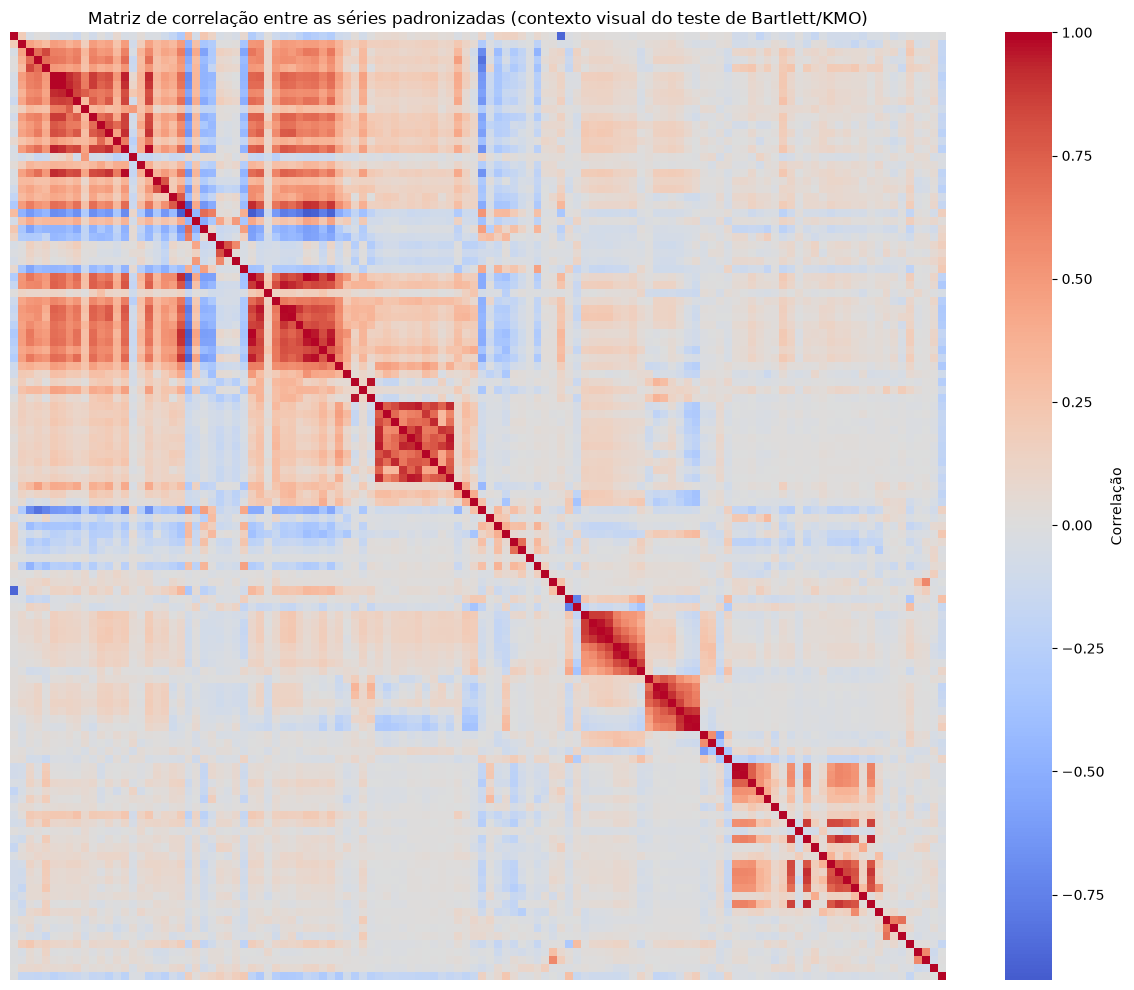

Figura salva: correlation_heatmap.png


In [16]:
# Heatmap da correlação entre as séries, sem anotar valores (118 séries ficariam ilegíveis).
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    pd.DataFrame(R, index=df_standardized.columns, columns=df_standardized.columns),
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Correlação"},
    xticklabels=False,
    yticklabels=False,
    ax=ax,
)
ax.set_title("Matriz de correlação entre as séries padronizadas (contexto visual do teste de Bartlett/KMO)")
plt.tight_layout()
plt.savefig(FIGURAS / "correlation_heatmap.png", dpi=150)
plt.show()
print("Figura salva: correlation_heatmap.png")


In [17]:
try:
    from factor_analyzer.factor_analyzer import calculate_kmo
    kmo_per_variable, kmo_global = calculate_kmo(df_standardized)
    kmo_source = "factor_analyzer"
except ImportError:
    # KMO manual: soma de r² / (soma de r² + soma de q²), com Q = matriz de correlações parciais
    R_inv = np.linalg.inv(R)
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(R_inv)))
    partial_corr = -D_inv_sqrt @ R_inv @ D_inv_sqrt
    np.fill_diagonal(partial_corr, 0)
    np.fill_diagonal(R, 0)

    r2 = R ** 2
    q2 = partial_corr ** 2
    kmo_per_variable = r2.sum(axis=1) / (r2.sum(axis=1) + q2.sum(axis=1))
    kmo_global = r2.sum() / (r2.sum() + q2.sum())

    np.fill_diagonal(R, 1)  # restaura a diagonal

def kmo_label(k):
    if k >= 0.90: return "Maravilhoso"
    elif k >= 0.80: return "Meritório"
    elif k >= 0.70: return "Mediano"
    elif k >= 0.60: return "Medíocre"
    elif k >= 0.50: return "Miserável"
    else: return "Inaceitável"

print("=" * 50)
print(f"Kaiser-Meyer-Olkin (KMO)")
print("=" * 50)
print(f"  KMO global = {kmo_global:.4f}  →  {kmo_label(kmo_global)}")
print()

kmo_series = pd.Series(kmo_per_variable, index=df_standardized.columns, name="KMO")
print(f"  Variáveis com KMO < 0,50 (problemáticas): "
      f"{(kmo_series < 0.50).sum()}")
print(f"  Variáveis com KMO ≥ 0,90 (maravilhosas):  "
      f"{(kmo_series >= 0.90).sum()}")
print()

if kmo_global >= 0.50:
    print(f"\n  → KMO = {kmo_global:.4f} ≥ 0,50. ✅ Dados fatoráveis.")
else:
    print(f"\n  → KMO = {kmo_global:.4f} < 0,50. ⚠️ Dados não fatoráveis.")

Kaiser-Meyer-Olkin (KMO)
  KMO global = 0.8039  →  Meritório

  Variáveis com KMO < 0,50 (problemáticas): 15
  Variáveis com KMO ≥ 0,90 (maravilhosas):  24


  → KMO = 0.8039 ≥ 0,50. ✅ Dados fatoráveis.


/media/doald533/HD/github/compsci-squad/tcc2/.venv/lib/python3.12/site-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [18]:
# k = menor número de componentes que acumula 70% da variância; é esse k que vai pro K-Means.
pca_full    = PCA().fit(df_standardized)
explained   = pca_full.explained_variance_ratio_
cumulative  = np.cumsum(explained)

k_70 = int(np.argmax(cumulative >= 0.70)) + 1


print("=" * 55)
print("Análise de Componentes Principais — Seleção de k")
print("=" * 55)
print(f"  PC1 explica              : {explained[0]*100:.1f}% da variância total")
print(f"  k (≥ 70% acumulado)      : {k_70}  componentes → {cumulative[k_70-1]*100:.1f}%")
print()
print(f"  ► K adotado para k-means : {k_70}")
print()

n_show = 19
summary_pca = pd.DataFrame({
    "variancia_%":   explained[:n_show] * 100,
    "acumulada_%":   cumulative[:n_show] * 100,
}, index=range(1, n_show + 1))
summary_pca.index.name = "PC"
print(summary_pca.round(2).to_string())

Análise de Componentes Principais — Seleção de k
  PC1 explica              : 19.6% da variância total
  k (≥ 70% acumulado)      : 19  componentes → 70.2%

  ► K adotado para k-means : 19

    variancia_%  acumulada_%
PC                          
1         19.55        19.55
2          7.49        27.05
3          6.74        33.78
4          5.49        39.27
5          4.89        44.16
6          3.34        47.50
7          2.52        50.02
8          2.41        52.43
9          2.11        54.54
10         1.89        56.44
11         1.87        58.31
12         1.73        60.03
13         1.71        61.74
14         1.63        63.37
15         1.58        64.95
16         1.43        66.38
17         1.34        67.72
18         1.27        68.99
19         1.21        70.20


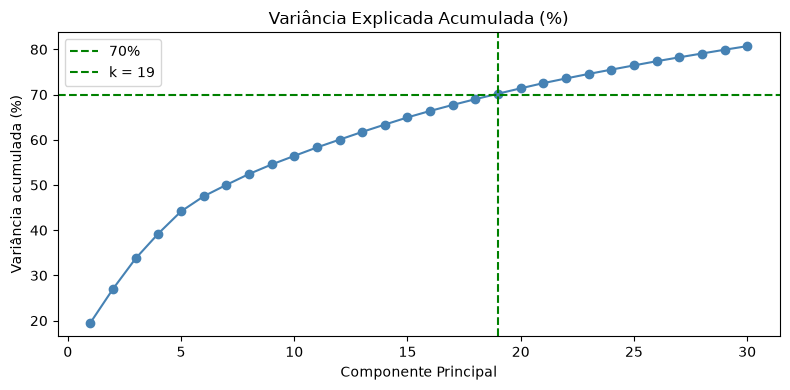

Figura salva: scree_plot.png  |  K adotado para k-means = 19


In [19]:
import matplotlib.pyplot as plt

n_show = 30
comp   = range(1, n_show + 1)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(comp, cumulative[:n_show] * 100, marker="o", color="steelblue")
ax.axhline(70, color="green",   linestyle="--", label="70%")
ax.axvline(k_70, color="green", linestyle="--", label=f"k = {k_70}")
ax.set_title("Variância Explicada Acumulada (%)")
ax.set_xlabel("Componente Principal")
ax.set_ylabel("Variância acumulada (%)")
ax.legend()

plt.tight_layout()
plt.savefig(FIGURAS / "scree_plot.png", dpi=150)
plt.show()
print(f"Figura salva: scree_plot.png  |  K adotado para k-means = {k_70}")

In [20]:
from sklearn.cluster import KMeans

print(f"Shape em memória: {df_standardized.shape}  ({df_standardized.shape[0]} obs × {df_standardized.shape[1]} séries)")

# Transpõe: cada série vira um ponto no espaço dos meses
X = df_standardized.T.values
series_names = df_standardized.columns.tolist()
print(f"Shape para clustering (séries × obs): {X.shape}")

# K vem do critério de 70% de variância explicada (célula do PCA)
K = 19

kmeans = KMeans(
    n_clusters=K,
    init="k-means++",
    n_init=20,
    max_iter=500,
    random_state=42,
)
kmeans.fit(X)

labels = kmeans.labels_
inertia = kmeans.inertia_

print(f"K-Means concluído.")
print(f"  k          = {K}")
print(f"  Inércia    = {inertia:,.2f}")
print(f"  Iterações  = {kmeans.n_iter_}")

clusters = pd.DataFrame({
    "serie":   series_names,
    "cluster": labels,
}).sort_values(["cluster", "serie"]).reset_index(drop=True)

clusters.to_csv(TABELAS / "clusters.csv", index=False)
print(f"Salvo: clusters.csv  ({len(clusters)} séries × 2 colunas)")
clusters

print("Séries por cluster:\n")
for g in sorted(clusters["cluster"].unique()):
    membros = clusters.loc[clusters["cluster"] == g, "serie"].tolist()
    print(f"  Cluster {g:2d} ({len(membros):2d} séries): {', '.join(membros)}")

Shape em memória: (735, 118)  (735 obs × 118 séries)
Shape para clustering (séries × obs): (118, 735)
K-Means concluído.
  k          = 19
  Inércia    = 36,807.71
  Iterações  = 4
Salvo: clusters.csv  (118 séries × 2 colunas)
Séries por cluster:

  Cluster  0 ( 7 séries): AAAFFM, BAAFFM, COMPAPFFx, T1YFFM, T5YFFM, TB3SMFFM, TB6SMFFM
  Cluster  1 (13 séries): AMDMNOx, AWOTMAN, CMRMTSPLx, CUMFNS, IPBUSEQ, IPCONGD, IPDCONGD, IPDMAT, IPFINAL, IPFPNSS, IPMANSICS, IPMAT, IPNMAT
  Cluster  2 (10 séries): HOUST, HOUSTMW, HOUSTNE, HOUSTS, HOUSTW, PERMIT, PERMITMW, PERMITNE, PERMITS, PERMITW
  Cluster  3 ( 5 séries): BUSLOANS, CLAIMSx, ISRATIOx, UEMPLT5, UNRATE
  Cluster  4 ( 8 séries): AAA, BAA, CP3Mx, GS1, GS10, GS5, TB3MS, TB6MS
  Cluster  5 ( 2 séries): IPB51222S, IPNCONGD
  Cluster  6 ( 7 séries): M1SL, OILPRICEx, PPICMM, WPSFD49207, WPSFD49502, WPSID61, WPSID62
  Cluster  7 ( 6 séries): AMDMUOx, AWHMAN, BUSINVx, CES0600000007, CES1021000001, EXUSUKx
  Cluster  8 ( 3 séries): DTCOLNVHFNM, 

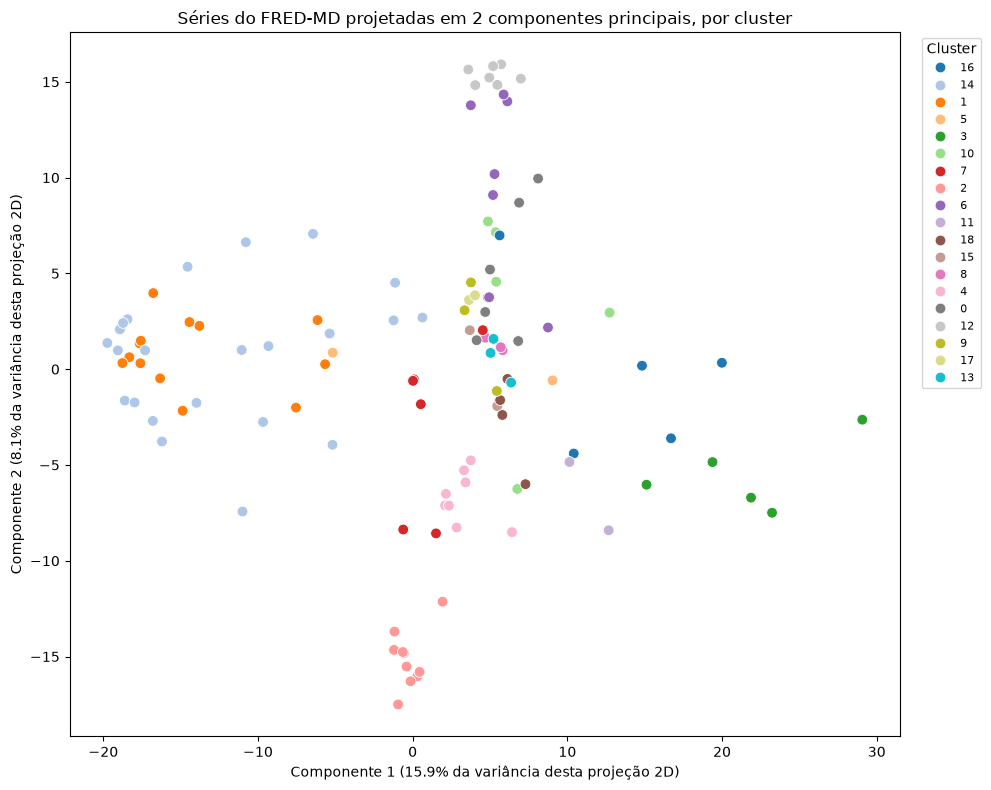

Figura salva: clusters_pca_scatter.png


In [21]:
# PCA de 2 componentes só para plotar. Não é o mesmo PCA do pca_full, que serve para escolher k.
pca_2d = PCA(n_components=2, random_state=42)
coords_2d = pca_2d.fit_transform(X)

df_plot = pd.DataFrame({
    "PC1": coords_2d[:, 0],
    "PC2": coords_2d[:, 1],
    "cluster": labels.astype(str),
})

fig, ax = plt.subplots(figsize=(10, 8))
sns.scatterplot(
    data=df_plot, x="PC1", y="PC2", hue="cluster",
    palette="tab20", s=60, ax=ax,
)
ax.set_title("Séries do FRED-MD projetadas em 2 componentes principais, por cluster")
ax.set_xlabel(f"Componente 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% da variância desta projeção 2D)")
ax.set_ylabel(f"Componente 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% da variância desta projeção 2D)")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(FIGURAS / "clusters_pca_scatter.png", dpi=150)
plt.show()
print("Figura salva: clusters_pca_scatter.png")


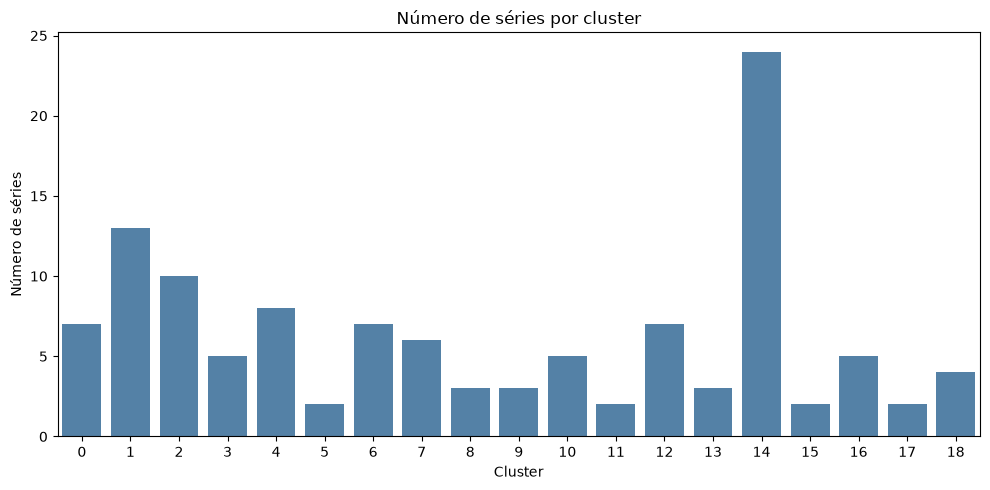

Figura salva: cluster_sizes.png


In [22]:
cluster_sizes = clusters["cluster"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(x=cluster_sizes.index, y=cluster_sizes.values, color="steelblue", ax=ax)
ax.set_title("Número de séries por cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Número de séries")
plt.tight_layout()
plt.savefig(FIGURAS / "cluster_sizes.png", dpi=150)
plt.show()
print("Figura salva: cluster_sizes.png")


In [23]:
# Etapa 5: regressão do centroide de cada cluster contra as 6 séries de referência, com
# Durbin-Watson e Breusch-Godfrey. nlags=4 (~1 trimestre, dados mensais) foi fixado antes do diagnóstico.
# O Breusch-Godfrey rejeitou H0 (sem autocorrelação) em todos os 19 clusters, o que só vimos depois de rodar.
# Por isso o modelo usa erro-padrão HAC (Newey-West) com o mesmo maxlags, já que o erro-padrão do OLS
# clássico não vale com resíduos autocorrelacionados. Coeficientes e R² não mudam, só erro-padrão, p-valores e F.
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_breusch_godfrey

BG_NLAGS = 4
reg_vars = X_reg.columns.tolist()

linhas_regressao = []
for cluster_id in sorted(clusters["cluster"].unique()):
    # centroide: um valor por data, então o índice é df_standardized.index
    y_full = pd.Series(kmeans.cluster_centers_[cluster_id], index=df_standardized.index)
    y_full.index = pd.to_datetime(y_full.index)

    # janela comum com as 6 séries de referência
    datas_comuns = y_full.index.intersection(X_reg.index)
    y = y_full.loc[datas_comuns]
    X_c = X_reg.loc[datas_comuns]

    modelo = sm.OLS(y, sm.add_constant(X_c)).fit(
        cov_type="HAC", cov_kwds={"maxlags": BG_NLAGS}
    )

    dw = durbin_watson(modelo.resid)
    bg_stat, bg_pvalue, _, _ = acorr_breusch_godfrey(modelo, nlags=BG_NLAGS)

    linha = {
        "cluster": cluster_id,
        "n_obs": int(modelo.nobs),
        "r_squared": modelo.rsquared,
        "f_stat": modelo.fvalue,
        "f_pvalue": modelo.f_pvalue,
        "durbin_watson": dw,
        "bg_stat": bg_stat,
        "bg_pvalue": bg_pvalue,
    }
    for var in ["const"] + reg_vars:
        linha[f"coef_{var}"] = modelo.params.get(var, np.nan)
        linha[f"pvalue_{var}"] = modelo.pvalues.get(var, np.nan)

    linhas_regressao.append(linha)

resultados_regressao = pd.DataFrame(linhas_regressao)
resultados_regressao.to_csv(TABELAS / "regressao_resultados.csv", index=False)

print(f"Janela comum usada em todas as regressões: {X_reg.index[0].date()} → {X_reg.index[-1].date()}")
print(f"Erro-padrão: HAC (Newey-West), maxlags={BG_NLAGS} — ver justificativa no comentário da célula")
print(f"Salvo: regressao_resultados.csv  ({resultados_regressao.shape[0]} clusters × {resultados_regressao.shape[1]} colunas)")
print()
print("Resumo por cluster:")
for _, row in resultados_regressao.iterrows():
    pvals_vars = {v: row[f"pvalue_{v}"] for v in reg_vars}
    var_menor_p = min(pvals_vars, key=pvals_vars.get)
    print(
        f"  Cluster {int(row['cluster']):2d}  "
        f"R²={row['r_squared']:.3f}  DW={row['durbin_watson']:.2f}  "
        f"BG p={row['bg_pvalue']:.3f}  "
        f"menor p-valor: {var_menor_p} (p={pvals_vars[var_menor_p]:.3g})"
    )

Janela comum usada em todas as regressões: 1973-02-01 → 2026-03-01
Erro-padrão: HAC (Newey-West), maxlags=4 — ver justificativa no comentário da célula
Salvo: regressao_resultados.csv  (19 clusters × 22 colunas)

Resumo por cluster:
  Cluster  0  R²=0.843  DW=0.35  BG p=0.000  menor p-valor: T10YFFM (p=6.13e-77)
  Cluster  1  R²=0.932  DW=2.34  BG p=0.000  menor p-valor: INDPRO (p=6.45e-190)
  Cluster  2  R²=0.100  DW=0.12  BG p=0.000  menor p-valor: INDPRO (p=0.00913)
  Cluster  3  R²=0.476  DW=2.13  BG p=0.000  menor p-valor: INDPRO (p=0.0017)
  Cluster  4  R²=0.455  DW=1.65  BG p=0.000  menor p-valor: FEDFUNDS (p=1.1e-22)
  Cluster  5  R²=0.098  DW=2.51  BG p=0.000  menor p-valor: INDPRO (p=0.000251)
  Cluster  6  R²=0.313  DW=2.90  BG p=0.000  menor p-valor: CPIAUCSL (p=6.42e-20)
  Cluster  7  R²=0.171  DW=0.50  BG p=0.000  menor p-valor: TWEXAFEGSMTHx (p=7.48e-08)
  Cluster  8  R²=0.013  DW=2.89  BG p=0.000  menor p-valor: CPIAUCSL (p=0.0426)
  Cluster  9  R²=0.087  DW=2.85  BG p=

In [24]:
# Comparação OLS clássico vs. HAC, só para deixar reproduzível o "9 dos 114 pares mudaram de
# significância" citado no artigo (antes esse número não saía do notebook). O modelo usado é o HAC.
linhas_comparacao = []
for cluster_id in sorted(clusters["cluster"].unique()):
    y_full = pd.Series(kmeans.cluster_centers_[cluster_id], index=df_standardized.index)
    y_full.index = pd.to_datetime(y_full.index)

    datas_comuns = y_full.index.intersection(X_reg.index)
    y = y_full.loc[datas_comuns]
    X_c = X_reg.loc[datas_comuns]

    # OLS clássico, só para comparar
    modelo_classico = sm.OLS(y, sm.add_constant(X_c)).fit()

    pvalues_hac_cluster = resultados_regressao.loc[
        resultados_regressao["cluster"] == cluster_id
    ].iloc[0]

    for var in reg_vars:
        p_classico = modelo_classico.pvalues.get(var, np.nan)
        p_hac = pvalues_hac_cluster[f"pvalue_{var}"]
        linhas_comparacao.append({
            "cluster": cluster_id,
            "variavel": var,
            "pvalue_ols_classico": p_classico,
            "pvalue_hac": p_hac,
            "mudou_significancia": (p_classico < 0.05) != (p_hac < 0.05),
        })

comparacao_ols_hac = pd.DataFrame(linhas_comparacao)
comparacao_ols_hac.to_csv(TABELAS / "regressao_comparacao_ols_hac.csv", index=False)

n_mudou = int(comparacao_ols_hac["mudou_significancia"].sum())
n_total = len(comparacao_ols_hac)
print(f"Pares (cluster, variável) comparados: {n_total} ({len(reg_vars)} variáveis x 19 clusters)")
print(f"Pares que mudaram de status de significância (limiar p<0.05) entre OLS clássico e HAC: {n_mudou}")
print("Salvo: regressao_comparacao_ols_hac.csv")


Pares (cluster, variável) comparados: 114 (6 variáveis x 19 clusters)
Pares que mudaram de status de significância (limiar p<0.05) entre OLS clássico e HAC: 9
Salvo: regressao_comparacao_ols_hac.csv


In [25]:
# Regressão de robustez: a mesma regressão (HAC, mesmos centroides) com 5 séries, sem o câmbio,
# na janela cheia 1965-2026. A análise principal continua sendo a de 6 séries (1973+).
reg_vars_5 = df_regressao.columns.tolist()

linhas_regressao_5 = []
for cluster_id in sorted(clusters["cluster"].unique()):
    y_full = pd.Series(kmeans.cluster_centers_[cluster_id], index=df_standardized.index)
    y_full.index = pd.to_datetime(y_full.index)

    # janela cheia, sem o corte do câmbio
    datas_comuns = y_full.index.intersection(df_regressao.index)
    y = y_full.loc[datas_comuns]
    X_c = df_regressao.loc[datas_comuns]

    modelo = sm.OLS(y, sm.add_constant(X_c)).fit(
        cov_type="HAC", cov_kwds={"maxlags": BG_NLAGS}
    )

    dw = durbin_watson(modelo.resid)
    bg_stat, bg_pvalue, _, _ = acorr_breusch_godfrey(modelo, nlags=BG_NLAGS)

    linha = {
        "cluster": cluster_id,
        "n_obs": int(modelo.nobs),
        "r_squared": modelo.rsquared,
        "f_stat": modelo.fvalue,
        "f_pvalue": modelo.f_pvalue,
        "durbin_watson": dw,
        "bg_stat": bg_stat,
        "bg_pvalue": bg_pvalue,
    }
    for var in ["const"] + reg_vars_5:
        linha[f"coef_{var}"] = modelo.params.get(var, np.nan)
        linha[f"pvalue_{var}"] = modelo.pvalues.get(var, np.nan)

    linhas_regressao_5.append(linha)

resultados_regressao_5series = pd.DataFrame(linhas_regressao_5)
resultados_regressao_5series.to_csv(TABELAS / "regressao_resultados_5series.csv", index=False)

print(f"Janela comum (5 séries, sem câmbio): {df_regressao.index[0].date()} → {df_regressao.index[-1].date()}")
print(f"Erro-padrão: HAC (Newey-West), maxlags={BG_NLAGS}")
print(f"Salvo: regressao_resultados_5series.csv  ({resultados_regressao_5series.shape[0]} clusters × {resultados_regressao_5series.shape[1]} colunas)")
print()

# Compara a variável dominante (menor p-valor) com e sem câmbio
print("Comparação R² e variável dominante — 6 séries (principal, com câmbio) vs 5 séries (robustez, sem câmbio):")
print()
for cluster_id in sorted(clusters["cluster"].unique()):
    row6 = resultados_regressao.loc[resultados_regressao["cluster"] == cluster_id].iloc[0]
    row5 = resultados_regressao_5series.loc[resultados_regressao_5series["cluster"] == cluster_id].iloc[0]

    pvals6 = {v: row6[f"pvalue_{v}"] for v in reg_vars}
    var6 = min(pvals6, key=pvals6.get)

    pvals5 = {v: row5[f"pvalue_{v}"] for v in reg_vars_5}
    var5 = min(pvals5, key=pvals5.get)

    marca = "  <-- MUDOU" if var6 != var5 else ""
    print(
        f"  Cluster {cluster_id:2d}  "
        f"6-séries: R²={row6['r_squared']:.3f} dom={var6:<14s}  |  "
        f"5-séries: R²={row5['r_squared']:.3f} dom={var5:<10s}"
        f"{marca}"
    )

Janela comum (5 séries, sem câmbio): 1965-01-01 → 2026-03-01
Erro-padrão: HAC (Newey-West), maxlags=4
Salvo: regressao_resultados_5series.csv  (19 clusters × 20 colunas)

Comparação R² e variável dominante — 6 séries (principal, com câmbio) vs 5 séries (robustez, sem câmbio):

  Cluster  0  6-séries: R²=0.843 dom=T10YFFM         |  5-séries: R²=0.829 dom=T10YFFM   
  Cluster  1  6-séries: R²=0.932 dom=INDPRO          |  5-séries: R²=0.931 dom=INDPRO    
  Cluster  2  6-séries: R²=0.100 dom=INDPRO          |  5-séries: R²=0.084 dom=INDPRO    
  Cluster  3  6-séries: R²=0.476 dom=INDPRO          |  5-séries: R²=0.450 dom=INDPRO    
  Cluster  4  6-séries: R²=0.455 dom=FEDFUNDS        |  5-séries: R²=0.424 dom=FEDFUNDS  
  Cluster  5  6-séries: R²=0.098 dom=INDPRO          |  5-séries: R²=0.099 dom=INDPRO    
  Cluster  6  6-séries: R²=0.313 dom=CPIAUCSL        |  5-séries: R²=0.288 dom=CPIAUCSL  
  Cluster  7  6-séries: R²=0.171 dom=TWEXAFEGSMTHx   |  5-séries: R²=0.119 dom=INDPRO      <

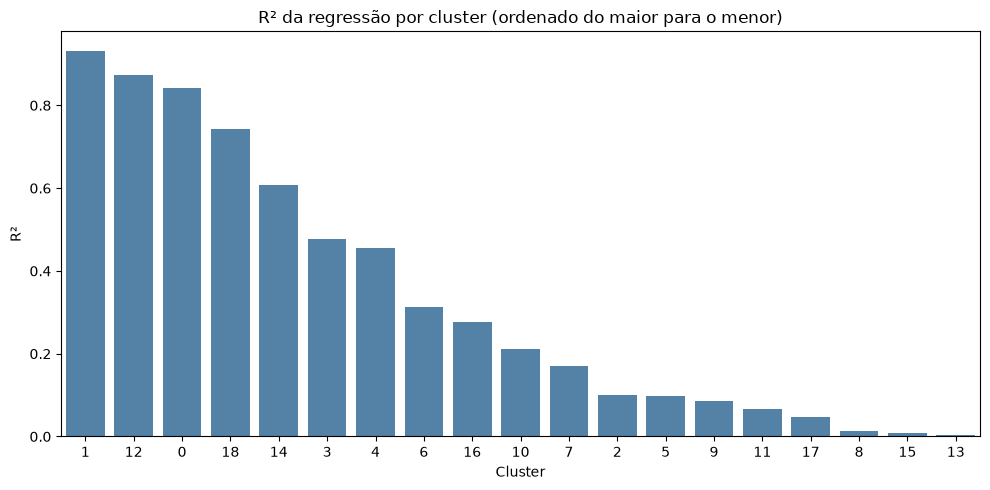

Figura salva: r2_por_cluster.png


In [26]:
r2_sorted = resultados_regressao[["cluster", "r_squared"]].sort_values("r_squared", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    x=r2_sorted["cluster"].astype(str),
    y=r2_sorted["r_squared"],
    order=r2_sorted["cluster"].astype(str),
    color="steelblue",
    ax=ax,
)
ax.set_title("R² da regressão por cluster (ordenado do maior para o menor)")
ax.set_xlabel("Cluster")
ax.set_ylabel("R²")
plt.tight_layout()
plt.savefig(FIGURAS / "r2_por_cluster.png", dpi=150)
plt.show()
print("Figura salva: r2_por_cluster.png")


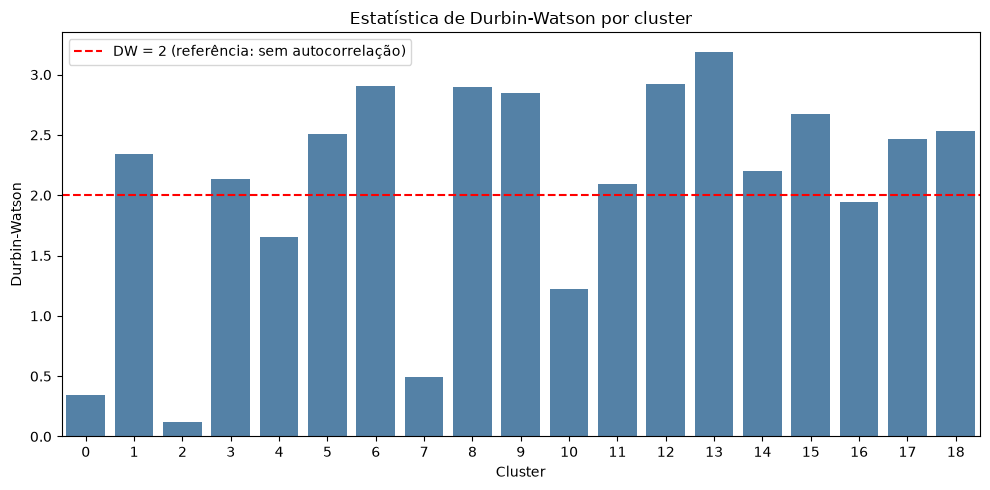

Figura salva: durbin_watson_por_cluster.png


In [27]:
# DW = 2 indica sem autocorrelação de 1ª ordem; a maioria dos clusters fica longe disso (ver Breusch-Godfrey).
dw_sorted = resultados_regressao[["cluster", "durbin_watson"]].sort_values("cluster")

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    x=dw_sorted["cluster"].astype(str),
    y=dw_sorted["durbin_watson"],
    color="steelblue",
    ax=ax,
)
ax.axhline(2, color="red", linestyle="--", label="DW = 2 (referência: sem autocorrelação)")
ax.set_title("Estatística de Durbin-Watson por cluster")
ax.set_xlabel("Cluster")
ax.set_ylabel("Durbin-Watson")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURAS / "durbin_watson_por_cluster.png", dpi=150)
plt.show()
print("Figura salva: durbin_watson_por_cluster.png")


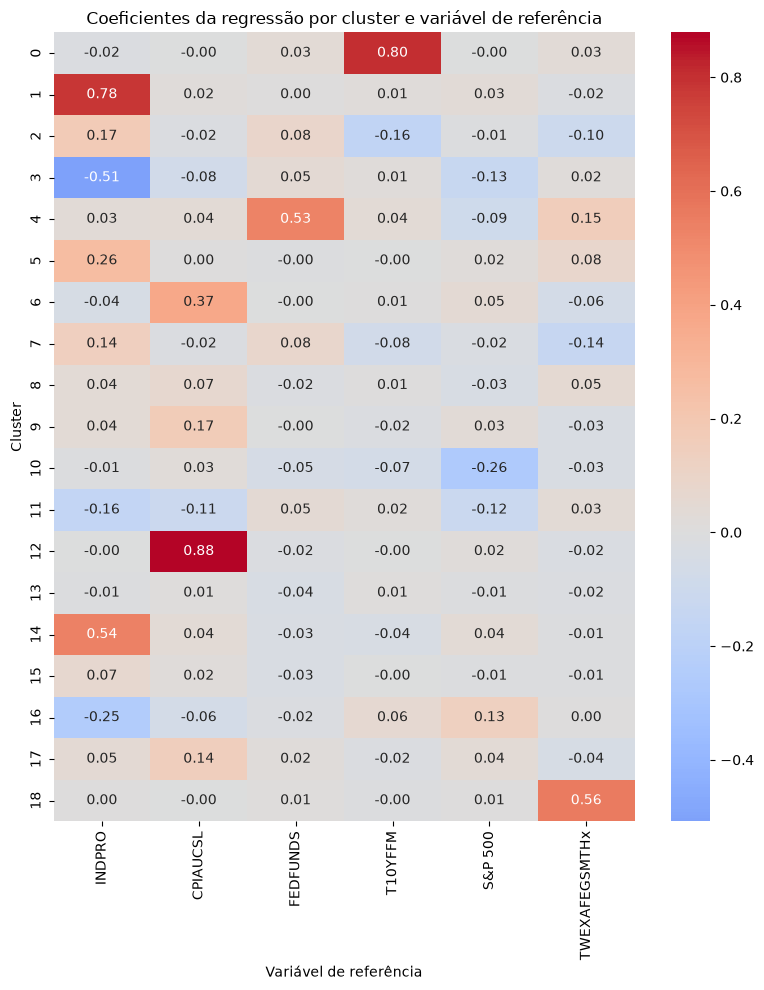

Figura salva: coeficientes_heatmap.png


In [28]:
coef_cols = [f"coef_{v}" for v in reg_vars]
coef_matrix = resultados_regressao.set_index("cluster")[coef_cols]
coef_matrix.columns = reg_vars

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(coef_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Coeficientes da regressão por cluster e variável de referência")
ax.set_xlabel("Variável de referência")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.savefig(FIGURAS / "coeficientes_heatmap.png", dpi=150)
plt.show()
print("Figura salva: coeficientes_heatmap.png")


In [29]:
# Tabela de evidência para a rotulagem: composição de cada cluster e variável de referência dominante.
# classificacao_familia só existe para os 7 clusters com R² > 0,4 (os outros ficam NaN). É julgamento do
# grupo a partir da composição dos clusters, validado pelo orientador, não cálculo.
# mesma_familia: membros são sub-índices da variável dominante (sanidade do método).
# mesma_familia_construcao: tautologia de construção (cluster 0). familia_diferente: achado.
CLASSIFICACAO_FAMILIA = {
    1: "mesma_familia",       # INDPRO; sub-índices de produção industrial
    12: "mesma_familia",      # CPIAUCSL; sub-índices de preço ao consumidor
    0: "mesma_familia_construcao",  # T10YFFM; tautologia de construção "taxa - FFM" (orientador)
    18: "familia_diferente",  # câmbio; câmbio bilateral e reservas (orientador)
    14: "familia_diferente",  # INDPRO; mercado de trabalho e consumo
    3: "familia_diferente",   # INDPRO; crédito e mercado de trabalho
    4: "familia_diferente",   # FEDFUNDS; transmissão de política monetária (orientador)
}

# Rótulos propostos pelo grupo a partir das séries de cada cluster, validados pelo orientador.
ROTULO_PROPOSTO = {
    0: "Prêmios de prazo e de crédito sobre a taxa básica (sanidade do método, confirmado pelo orientador: tautologia de construção, os membros e a variável dominante T10YFFM compartilham o termo subtraído Fed Funds)",
    1: "Produção industrial (sanidade do método — membros são sub-índices oficiais do INDPRO)",
    2: "Construção residencial",
    3: "Crédito e desemprego de curto prazo",
    4: "Curva de juros e custo de crédito",
    5: "Produção de bens de consumo não duráveis",
    6: "Preços ao produtor e commodities",
    7: "Horas trabalhadas e estoques industriais (variável dominante instável entre câmbio e INDPRO conforme a regressão de robustez)",
    8: "Crédito ao consumidor (sem relação clara com as 6 variáveis de referência)",
    9: "Preços de serviços e saúde",
    10: "Volatilidade de mercado e desemprego de longa duração",
    11: "Base monetária e reservas bancárias",
    12: "Núcleo de inflação ao consumidor (sanidade do método — membros são sub-índices oficiais do CPIAUCSL)",
    13: "Salários (sem relação clara com as 6 variáveis de referência)",
    14: "Emprego e consumo — atividade real ampla",
    15: "Crédito imobiliário bancário (sem relação clara com as 6 variáveis de referência)",
    16: "Agregados monetários e avaliação de mercado",
    17: "Preços de bens duráveis",
    18: "Câmbio e reservas bancárias",
}

linhas_rotulo = []
for cluster_id in sorted(clusters["cluster"].unique()):
    membros = clusters.loc[clusters["cluster"] == cluster_id, "serie"].tolist()
    row_reg = resultados_regressao.loc[resultados_regressao["cluster"] == cluster_id].iloc[0]

    pvals_vars = {v: row_reg[f"pvalue_{v}"] for v in reg_vars}
    variavel_dominante = min(pvals_vars, key=pvals_vars.get)

    linhas_rotulo.append({
        "cluster": cluster_id,
        "n_series": len(membros),
        "series_membro": ", ".join(membros),
        "variavel_dominante": variavel_dominante,
        "pvalue_dominante": pvals_vars[variavel_dominante],
        "r_squared": row_reg["r_squared"],
        "durbin_watson": row_reg["durbin_watson"],
        "bg_pvalue": row_reg["bg_pvalue"],
        "classificacao_familia": CLASSIFICACAO_FAMILIA.get(cluster_id, np.nan),
        "rotulo_proposto": ROTULO_PROPOSTO.get(cluster_id, np.nan),
    })

clusters_rotulados = pd.DataFrame(linhas_rotulo).sort_values("cluster").reset_index(drop=True)
clusters_rotulados.to_csv(TABELAS / "clusters_rotulados.csv", index=False)

print(f"Salvo: clusters_rotulados.csv  ({clusters_rotulados.shape[0]} clusters)")
print()
with pd.option_context("display.max_colwidth", 80):
    print(clusters_rotulados.to_string(index=False))

Salvo: clusters_rotulados.csv  (19 clusters)

 cluster  n_series                                                                                                                                                                                                          series_membro variavel_dominante  pvalue_dominante  r_squared  durbin_watson     bg_pvalue    classificacao_familia                                                                                                                                                                                                  rotulo_proposto
       0         7                                                                                                                                                          AAAFFM, BAAFFM, COMPAPFFx, T1YFFM, T5YFFM, TB3SMFFM, TB6SMFFM            T10YFFM      6.133921e-77   0.842978       0.346917 2.314266e-100 mesma_familia_construcao Prêmios de prazo e de crédito sobre a taxa básica (sanidade do método, co

In [30]:
_tcode_labels = {
    1: "nível",
    2: "Δx",
    3: "Δ²x",
    4: "ln(x)",
    5: "Δln(x)",
    6: "Δ²ln(x)",
    7: "Δ(pct_change)",
}

summary = pd.DataFrame(
    {
        "tcode": tcode.astype(int),
        "transformacao": [_tcode_labels[int(c)] for c in tcode],
    },
    index=df.columns,
)
summary.index.name = "serie"

print("Distribuição de transformações:")
print(summary["transformacao"].value_counts().to_string())
print()
summary

Distribuição de transformações:
transformacao
Δln(x)           52
Δ²ln(x)          33
Δx               19
nível            11
ln(x)            10
Δ(pct_change)     1



,tcode,transformacao
serie,,
RPI,5,Δln(x)
W875RX1,5,Δln(x)
DPCERA3M086SBEA,5,Δln(x)
CMRMTSPLx,5,Δln(x)
RETAILx,5,Δln(x)
...,...,...
UMCSENTx,2,Δx
DTCOLNVHFNM,6,Δ²ln(x)
DTCTHFNM,6,Δ²ln(x)


In [31]:
# Bootstrap de estabilidade dos clusters de achado genuíno (3, 4, 14, 18).
# É block bootstrap, não o bootstrap tradicional: as séries têm autocorrelação forte e sortear meses
# isolados destruiria essa dependência. Os blocos são contíguos (12 meses) e os mesmos para as 118
# séries, para preservar a correlação entre elas, que é o que o K-Means usa para formar os clusters.
# O tamanho de bloco veio do roteiro do orientador, não foi ajustado depois de ver o Jaccard.
BLOCK_SIZE = 12  # meses
CLUSTERS_ALVO = [3, 4, 14, 18]  # classificacao_familia == "familia_diferente"

# X, K e series_names vêm da célula do K-Means.


def moving_block_bootstrap_matrix(X_original, block_size, rng):
    """Reamostra o tempo (colunas) em blocos contíguos com reposição, mesmos blocos para todas as séries.
    O último bloco é truncado para manter o comprimento original.
    """
    n_series, n_time = X_original.shape
    n_blocks_needed = int(np.ceil(n_time / block_size))
    max_start = n_time - block_size  # último início válido de um bloco completo

    block_starts = rng.integers(0, max_start + 1, size=n_blocks_needed)

    blocos = [X_original[:, start:start + block_size] for start in block_starts]
    X_resampled = np.concatenate(blocos, axis=1)[:, :n_time]
    return X_resampled


def cluster_com_maior_overlap(membros_originais, labels_reamostra, series_names):
    """Jaccard do cluster reamostrado que mais se sobrepõe ao conjunto original de séries."""
    membros_originais = set(membros_originais)
    melhor_jaccard = 0.0
    for cluster_id in np.unique(labels_reamostra):
        membros_reamostra = {series_names[i] for i in np.where(labels_reamostra == cluster_id)[0]}
        intersecao = membros_originais & membros_reamostra
        uniao = membros_originais | membros_reamostra
        jaccard = len(intersecao) / len(uniao) if uniao else 0.0
        if jaccard > melhor_jaccard:
            melhor_jaccard = jaccard
    return melhor_jaccard


membros_originais_por_cluster = {
    cid: clusters.loc[clusters["cluster"] == cid, "serie"].tolist()
    for cid in CLUSTERS_ALVO
}
print("Séries-membro originais dos 4 clusters de achado genuíno:")
for cid in CLUSTERS_ALVO:
    print(f"  Cluster {cid}: {len(membros_originais_por_cluster[cid])} séries")


Séries-membro originais dos 4 clusters de achado genuíno:
  Cluster 3: 5 séries
  Cluster 4: 8 séries
  Cluster 14: 24 séries
  Cluster 18: 4 séries


In [32]:
import time

# Gerador com seed fixa, separado do random_state=42 do K-Means original.
rng_bootstrap = np.random.default_rng(42)

# B = 500 (roteiro do orientador). Mede o tempo de uma iteração e só reduz B se a projeção passar
# de ~25 min; essa decisão usa só o relógio, antes de qualquer resultado de Jaccard.
rng_teste_tempo = np.random.default_rng(0)
t0 = time.time()
X_teste = moving_block_bootstrap_matrix(X, BLOCK_SIZE, rng_teste_tempo)
KMeans(n_clusters=K, init="k-means++", n_init=20, max_iter=500, random_state=0).fit(X_teste)
tempo_uma_iteracao = time.time() - t0

B_PLANEJADO = 500
tempo_projetado_min = tempo_uma_iteracao * B_PLANEJADO / 60
print(f"Tempo de 1 iteração de teste: {tempo_uma_iteracao:.2f}s")
print(f"Tempo projetado para B={B_PLANEJADO}: {tempo_projetado_min:.1f} min")

if tempo_projetado_min > 25:
    B = 100
    print(f"Projeção acima de ~25 min -> reduzindo para B={B} POR CUSTO "
          f"COMPUTACIONAL (decisão tomada agora, olhando só o tempo estimado, "
          f"antes de rodar qualquer reamostragem real ou ver resultado de Jaccard).")
else:
    B = B_PLANEJADO
    print(f"Projeção dentro do orçamento de tempo -> mantendo B={B} como planejado a priori.")

# Em cada reamostra o K-Means é refeito por inteiro, com os mesmos parâmetros e k = 19 fixo;
# a imputação e a padronização não são refeitas.
jaccard_por_cluster = {cid: [] for cid in CLUSTERS_ALVO}

t_inicio = time.time()
for b in range(B):
    X_reamostrado = moving_block_bootstrap_matrix(X, BLOCK_SIZE, rng_bootstrap)

    kmeans_b = KMeans(
        n_clusters=K,
        init="k-means++",
        n_init=20,
        max_iter=500,
        random_state=b,
    )
    kmeans_b.fit(X_reamostrado)
    labels_b = kmeans_b.labels_

    for cid in CLUSTERS_ALVO:
        jaccard = cluster_com_maior_overlap(
            membros_originais_por_cluster[cid], labels_b, series_names
        )
        jaccard_por_cluster[cid].append(jaccard)

tempo_total_min = (time.time() - t_inicio) / 60
print(f"Concluído: B={B} reamostragens em {tempo_total_min:.1f} min.")


Tempo de 1 iteração de teste: 0.05s
Tempo projetado para B=500: 0.4 min
Projeção dentro do orçamento de tempo -> mantendo B=500 como planejado a priori.


Concluído: B=500 reamostragens em 0.4 min.


In [33]:
bootstrap_jaccard_clusters = pd.DataFrame([
    {
        "cluster": cid,
        "jaccard_medio": np.mean(jaccard_por_cluster[cid]),
        "jaccard_std": np.std(jaccard_por_cluster[cid], ddof=1),
        "n_reamostragens": B,
    }
    for cid in CLUSTERS_ALVO
]).sort_values("cluster").reset_index(drop=True)

bootstrap_jaccard_clusters.to_csv(TABELAS / "bootstrap_jaccard_clusters.csv", index=False)

print(f"Salvo: bootstrap_jaccard_clusters.csv  (B={B} reamostragens)")
print()
print(bootstrap_jaccard_clusters.to_string(index=False))


Salvo: bootstrap_jaccard_clusters.csv  (B=500 reamostragens)

 cluster  jaccard_medio  jaccard_std  n_reamostragens
       3       0.430379     0.222533              500
       4       0.716089     0.225832              500
      14       0.535099     0.137030              500
      18       0.396839     0.167423              500


In [34]:
# Estatística descritiva por cluster (Tabela 2 e Figura 1 do artigo de referência), calculada sobre
# o centroide do K-Means (735 meses), o mesmo objeto usado na regressão.
# Diferença em relação ao artigo: as séries foram padronizadas antes do agrupamento, então tudo está
# em desvios-padrão e não nas unidades originais (a Tabela 2 usa retornos brutos). A média do
# centroide é ~0 por construção; a coluna informativa é o desvio-padrão (perto de 1 = membros se
# movem juntos). Desvio e variância com ddof=1.

CORTE_R2_FORTE = 0.4  # mesmo corte da Etapa 6
CLUSTERS_FORTES = sorted(
    clusters_rotulados.loc[clusters_rotulados["r_squared"] > CORTE_R2_FORTE, "cluster"].tolist()
)
print(f"Clusters fortes (R² > {CORTE_R2_FORTE}): {CLUSTERS_FORTES}")

# centróides: um valor por data
datas = pd.to_datetime(df_standardized.index)
centroides = pd.DataFrame(
    kmeans.cluster_centers_.T, index=datas, columns=list(range(K))
)
centroides.index.name = "data"

n_series_por_cluster = clusters["cluster"].value_counts().sort_index()

# rótulo curto para títulos e legendas: trecho antes do primeiro parêntese
rotulo_por_cluster = clusters_rotulados.set_index("cluster")["rotulo_proposto"]
ROTULO_CURTO = {cid: str(rotulo_por_cluster[cid]).split(" (")[0] for cid in range(K)}

descritiva_clusters = pd.DataFrame({
    "cluster": list(range(K)),
    "n_series": [int(n_series_por_cluster[c]) for c in range(K)],
    "media": [centroides[c].mean() for c in range(K)],
    "desvio_padrao": [centroides[c].std(ddof=1) for c in range(K)],
    "minimo": [centroides[c].min() for c in range(K)],
    "maximo": [centroides[c].max() for c in range(K)],
    "variancia": [centroides[c].var(ddof=1) for c in range(K)],
    "rotulo_proposto": [rotulo_por_cluster[c] for c in range(K)],
})
descritiva_clusters.to_csv(TABELAS / "descritiva_clusters.csv", index=False)

print("Salvo: descritiva_clusters.csv")
print("Unidades: desvios-padrão da série padronizada (NÃO as unidades originais do FRED-MD).\n")
with pd.option_context("display.width", 200, "display.max_colwidth", 55):
    print(descritiva_clusters.assign(
        rotulo_proposto=descritiva_clusters["rotulo_proposto"].str.split(" \\(").str[0]
    ).round(3).to_string(index=False))

Clusters fortes (R² > 0.4): [0, 1, 3, 4, 12, 14, 18]
Salvo: descritiva_clusters.csv
Unidades: desvios-padrão da série padronizada (NÃO as unidades originais do FRED-MD).

 cluster  n_series  media  desvio_padrao  minimo  maximo  variancia                                       rotulo_proposto
       0         7    0.0          0.876  -5.314   1.683      0.768     Prêmios de prazo e de crédito sobre a taxa básica
       1        13   -0.0          0.813 -12.390   5.779      0.661                                   Produção industrial
       2        10    0.0          0.877  -2.859   1.759      0.769                                Construção residencial
       3         5   -0.0          0.739  -8.626  12.114      0.547                   Crédito e desemprego de curto prazo
       4         8    0.0          0.865  -7.920   4.106      0.748                     Curva de juros e custo de crédito
       5         2   -0.0          0.865  -3.522   2.997      0.748              Produção de bens

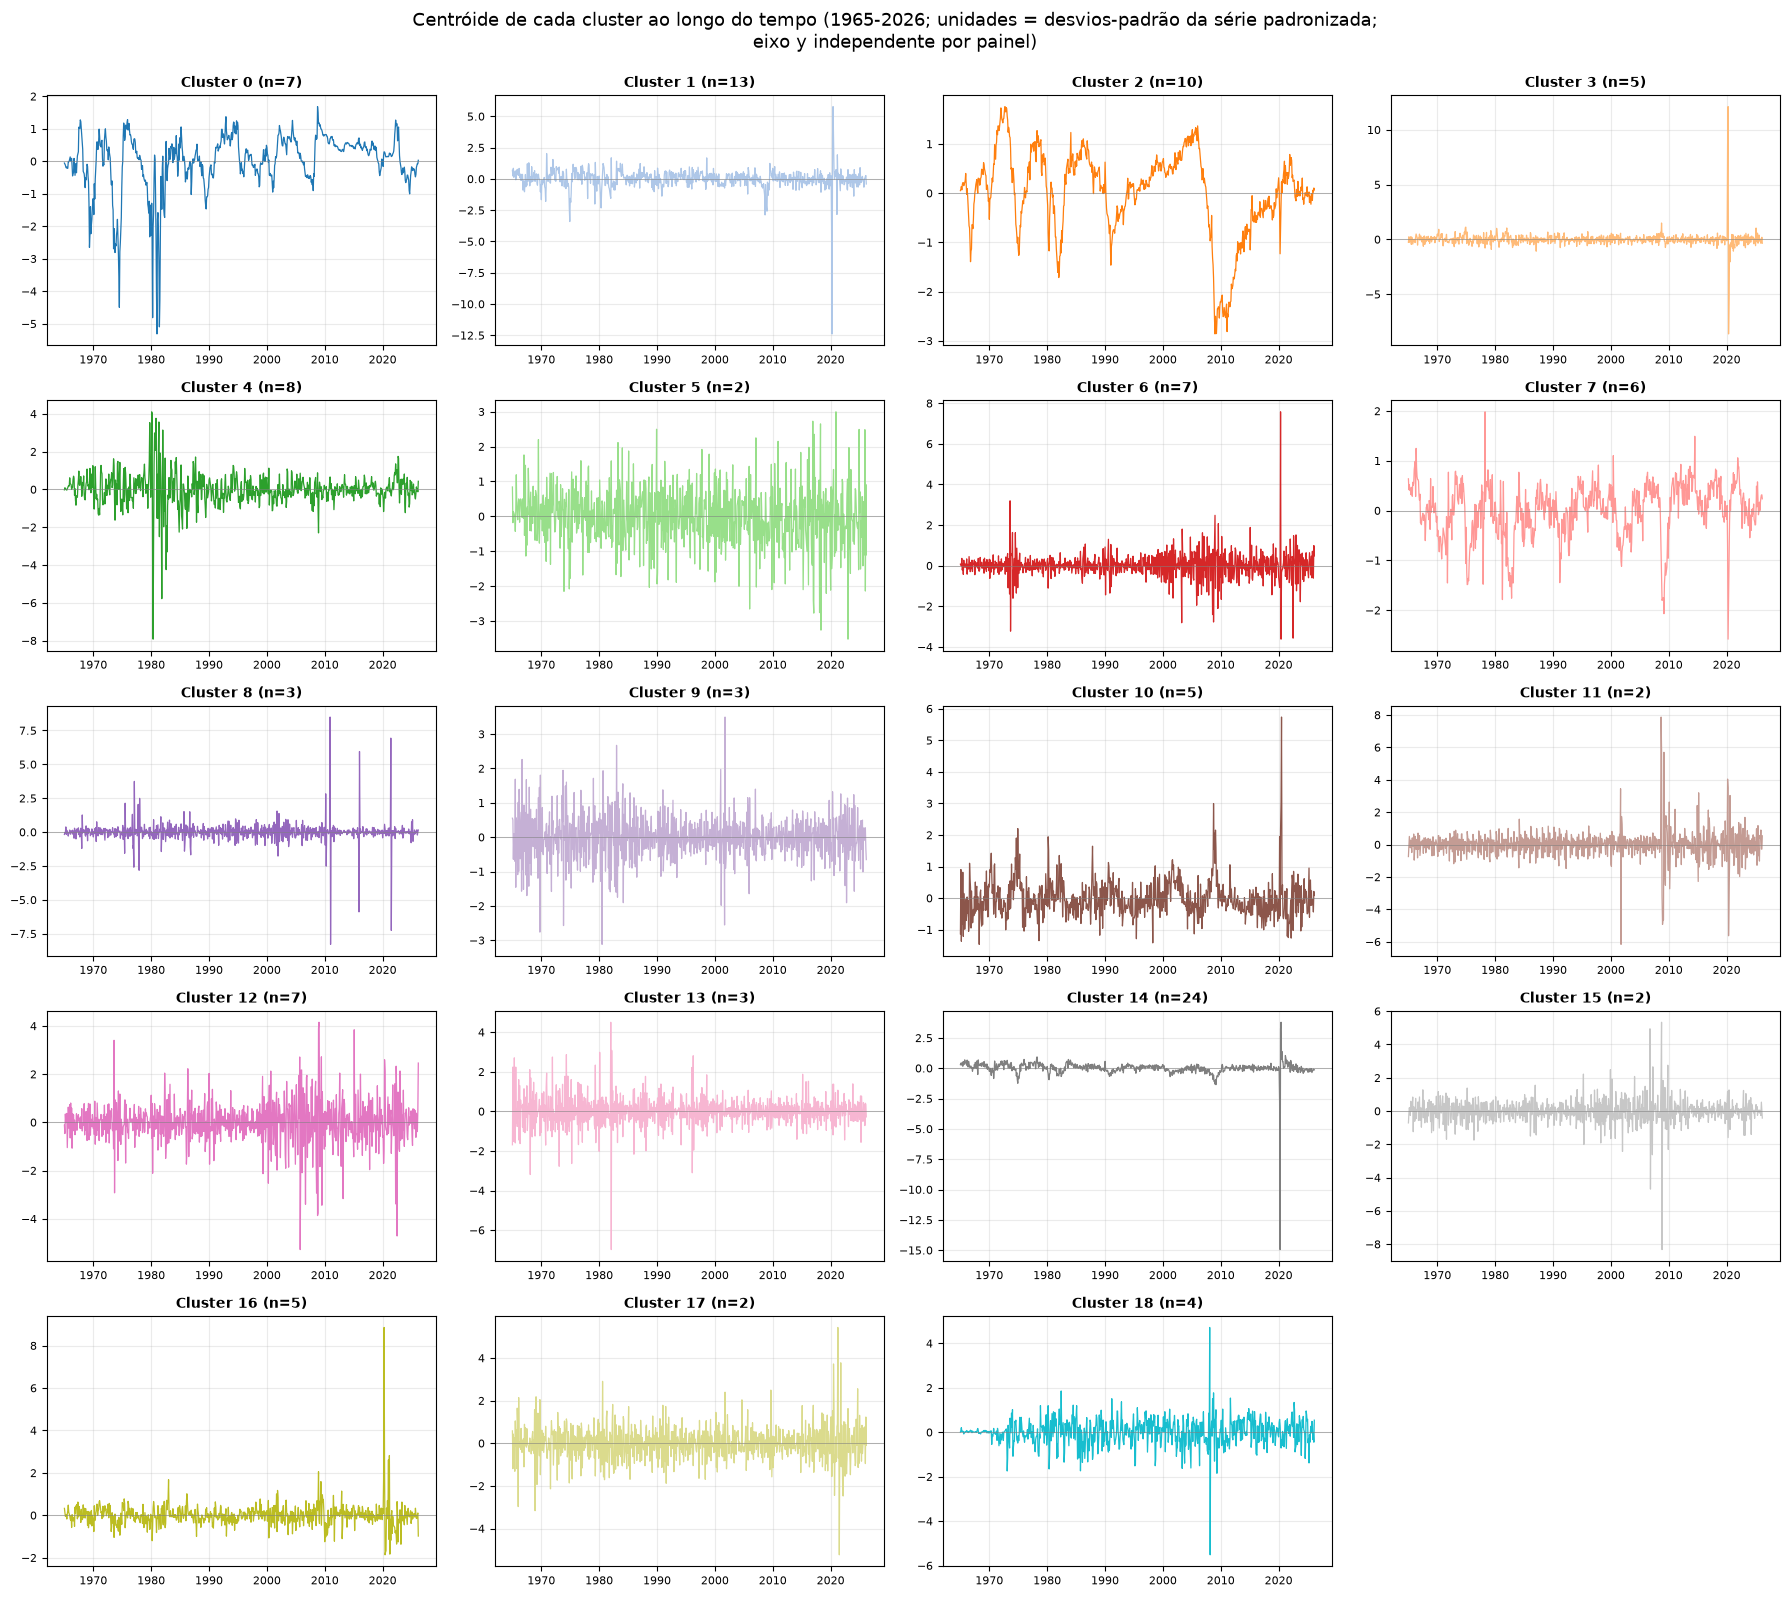

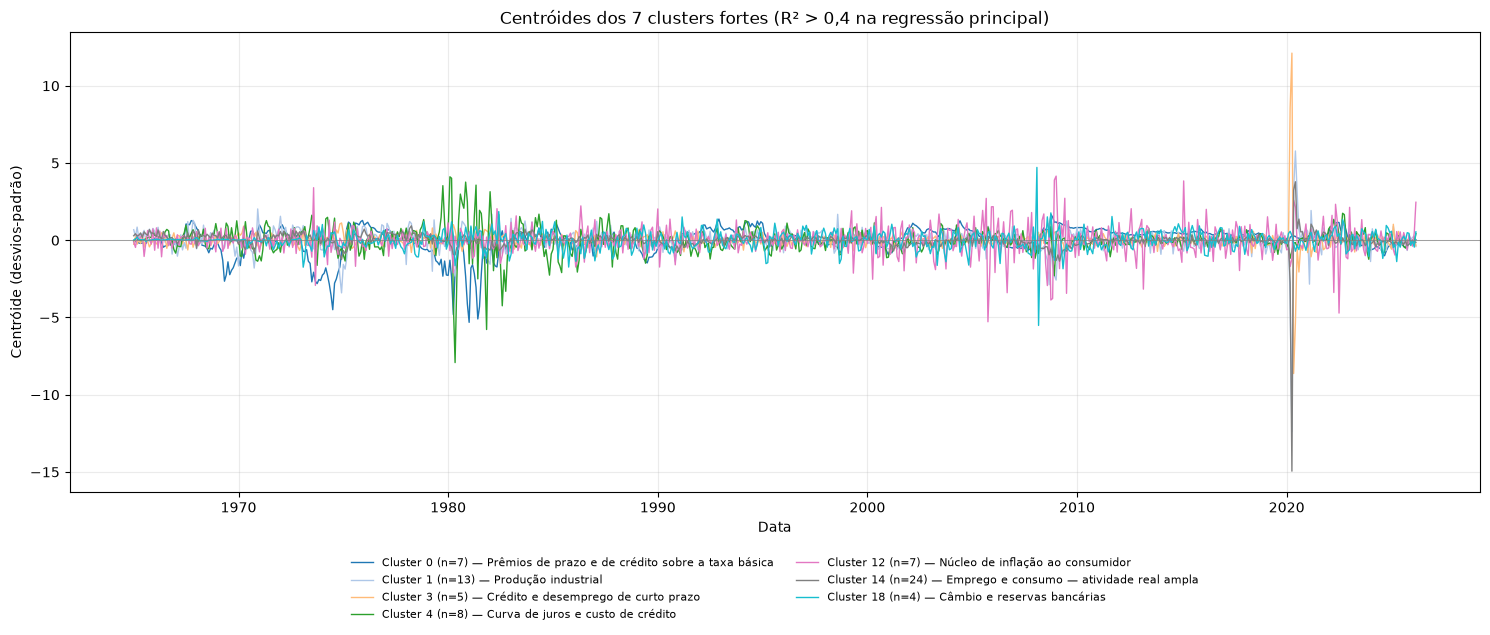

Salvos: centroides_por_cluster.png, centroides_clusters_fortes.png


In [35]:
# Figuras dos centróides. (a) um painel por cluster, com eixo y independente porque as amplitudes
# são muito diferentes (não dá pra comparar painéis a olho; a comparação numérica está em
# descritiva_clusters.csv). (b) só os 7 clusters fortes. Mesma cor tab20 da figura de rede.
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

cmap_tab20 = plt.get_cmap("tab20")
cor_cluster = {cid: cmap_tab20(cid % 20) for cid in range(K)}

# grade 5 x 4: 19 painéis e 1 vazio
fig, axes = plt.subplots(5, 4, figsize=(18, 16), sharex=True, sharey=False)
axes = axes.ravel()
for cid in range(K):
    ax = axes[cid]
    ax.plot(centroides.index, centroides[cid], color=cor_cluster[cid], lw=0.9)
    ax.axhline(0, color="gray", lw=0.4)
    ax.set_title(f"Cluster {cid} (n={int(n_series_por_cluster[cid])})", fontsize=10, fontweight="bold")
    ax.tick_params(labelsize=8)
    ax.grid(alpha=0.25)
for ax in axes[K:]:
    ax.set_visible(False)
for ax in axes[:K]:
    ax.xaxis.set_major_locator(mdates.YearLocator(10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(axis="x", labelbottom=True)
fig.suptitle(
    "Centróide de cada cluster ao longo do tempo (1965-2026; unidades = desvios-padrão da série padronizada;\n"
    "eixo y independente por painel)", fontsize=13, y=0.995
)
plt.tight_layout()
plt.savefig(FIGURAS / "centroides_por_cluster.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(15, 6.5))
for cid in CLUSTERS_FORTES:
    ax.plot(centroides.index, centroides[cid], lw=1.0, color=cor_cluster[cid],
            label=f"Cluster {cid} (n={int(n_series_por_cluster[cid])}) — {ROTULO_CURTO[cid]}")
ax.axhline(0, color="gray", lw=0.5)
ax.set_xlabel("Data")
ax.set_ylabel("Centróide (desvios-padrão)")
ax.set_title("Centróides dos 7 clusters fortes (R² > 0,4 na regressão principal)")
ax.grid(alpha=0.25)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, fontsize=8, frameon=False)
plt.tight_layout()
plt.savefig(FIGURAS / "centroides_clusters_fortes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvos: centroides_por_cluster.png, centroides_clusters_fortes.png")

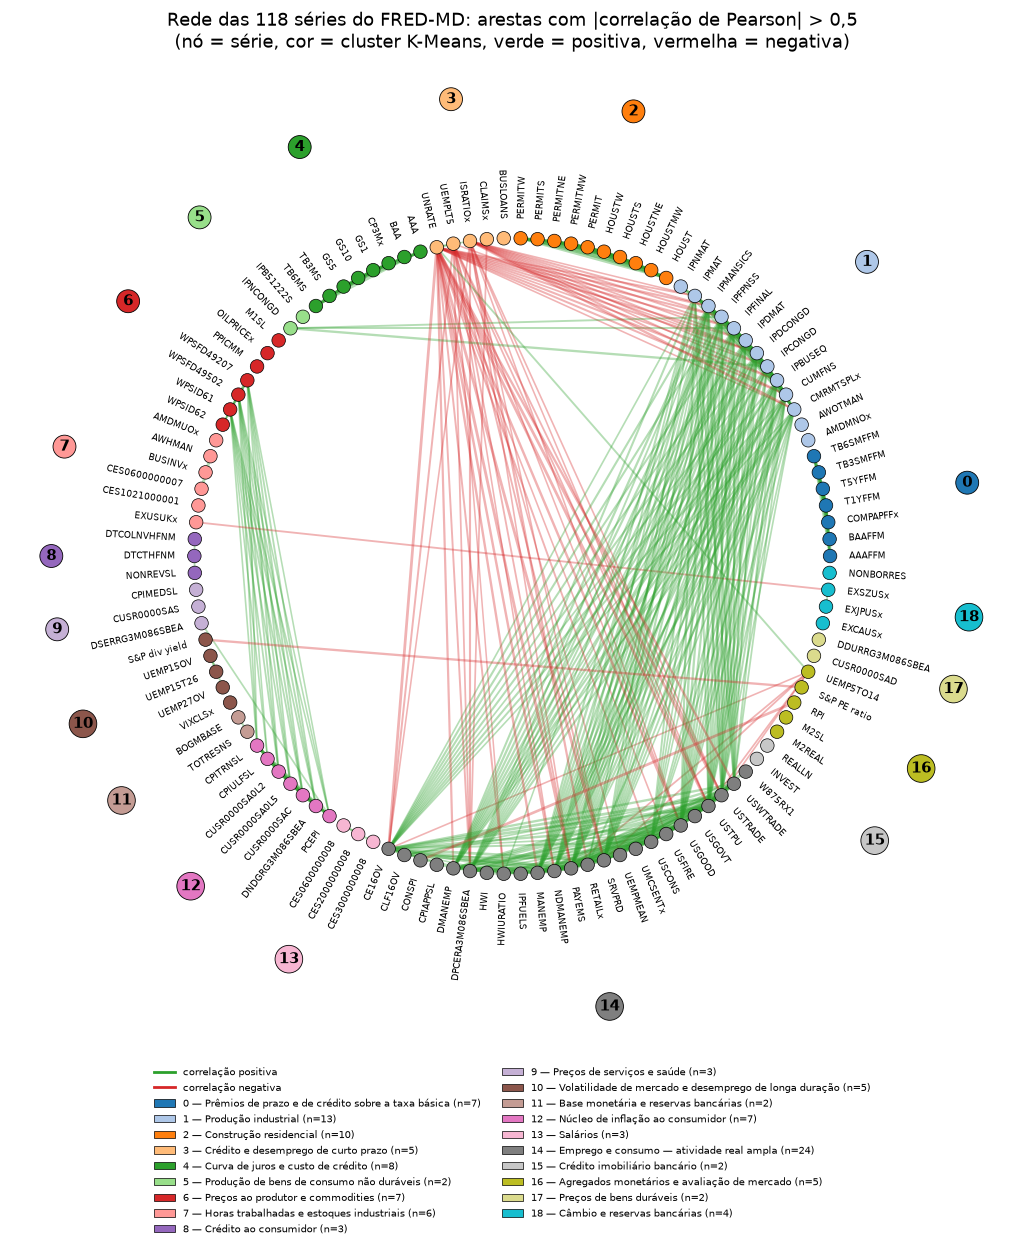

Salvo: rede_clusters.png  (limiar |r| > 0.5)
  Arestas: 471  |  positivas: 86.8%  |  negativas: 13.2%
  Dentro de clusters: 266 (56.5%)  |  entre clusters: 205 (43.5%)
  Densidade de arestas dentro de clusters: 48.0% dos pares possíveis; entre clusters: 3.2%
  Séries sem nenhuma aresta: 24 de 118


In [36]:
# Rede circular das 118 séries: nó = série (cor = cluster K-Means), aresta = |correlação de Pearson|
# acima de LIMIAR_CORR (verde = positiva, vermelha = negativa).
# Pearson porque, com séries padronizadas, a distância do K-Means é função da correlação. Mede só
# associação linear e contemporânea: a figura mostra co-movimento, não causalidade.
# O limiar 0,5 veio do roteiro do orientador e não foi ajustado depois de ver a figura.
import networkx as nx
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

LIMIAR_CORR = 0.5
corr_series = df_standardized.corr()

# ordenado por (cluster, nome) para os membros de um cluster ficarem juntos no círculo
cluster_de = dict(zip(clusters["serie"], clusters["cluster"]))
nos_ordenados = sorted(df_standardized.columns, key=lambda s: (cluster_de[s], s))


def montar_rede(limiar):
    """Grafo com um nó por série e uma aresta para cada par com |r| > limiar."""
    G = nx.Graph()
    G.add_nodes_from(nos_ordenados)
    for i, a in enumerate(nos_ordenados):
        for b in nos_ordenados[i + 1:]:
            r = corr_series.loc[a, b]
            if abs(r) > limiar:
                G.add_edge(a, b, corr=r)
    return G


def resumo_rede(G, limiar):
    arestas = list(G.edges(data="corr"))
    n_arestas = len(arestas)
    n_pos = sum(1 for _, _, r in arestas if r > 0)
    n_neg = n_arestas - n_pos
    n_dentro = sum(1 for a, b, _ in arestas if cluster_de[a] == cluster_de[b])
    n_entre = n_arestas - n_dentro
    # densidade e não só contagem, porque clusters grandes têm muito mais pares possíveis
    tam = clusters["cluster"].value_counts()
    pares_dentro = int(sum(n * (n - 1) // 2 for n in tam.values))
    pares_total = len(nos_ordenados) * (len(nos_ordenados) - 1) // 2
    pares_entre = pares_total - pares_dentro
    isolados = sum(1 for n in G.nodes if G.degree(n) == 0)
    return {
        "limiar": limiar, "n_arestas": n_arestas,
        "pct_positivas": 100 * n_pos / n_arestas if n_arestas else float("nan"),
        "pct_negativas": 100 * n_neg / n_arestas if n_arestas else float("nan"),
        "n_dentro": n_dentro, "n_entre": n_entre,
        "pct_dentro": 100 * n_dentro / n_arestas if n_arestas else float("nan"),
        "densidade_dentro": n_dentro / pares_dentro,
        "densidade_entre": n_entre / pares_entre,
        "nos_isolados": isolados,
    }


def desenhar_rede(G, limiar, caminho, titulo):
    pos = nx.circular_layout(G)
    fig, ax = plt.subplots(figsize=(12, 12.4))
    ax.set_aspect("equal")
    ax.axis("off")

    arestas = list(G.edges(data="corr"))
    # fracas primeiro, fortes por cima
    arestas.sort(key=lambda e: abs(e[2]))
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edgelist=[(a, b) for a, b, _ in arestas],
        edge_color=["#2ca02c" if r > 0 else "#d62728" for _, _, r in arestas],
        width=[2.2 * abs(r) for _, _, r in arestas],
        alpha=0.35,
    )
    nx.draw_networkx_nodes(
        G, pos, ax=ax, nodelist=nos_ordenados,
        node_color=[cor_cluster[cluster_de[s]] for s in nos_ordenados],
        node_size=95, edgecolors="black", linewidths=0.5,
    )

    # rótulos radiais, senão os 118 se sobrepõem
    for s in nos_ordenados:
        x, y = pos[s]
        ang = np.degrees(np.arctan2(y, x))
        esquerda = abs(ang) > 90
        ax.text(
            1.06 * x, 1.06 * y, s, fontsize=6.3,
            rotation=ang + 180 if esquerda else ang,
            ha="right" if esquerda else "left", va="center",
            rotation_mode="anchor",
        )

    # número do cluster no ângulo médio dos membros (tab20 repete cores parecidas)
    for cid in range(K):
        membros = [s for s in nos_ordenados if cluster_de[s] == cid]
        angs = np.array([np.arctan2(pos[s][1], pos[s][0]) for s in membros])
        # média circular, por causa do salto em pi
        ang_med = np.arctan2(np.sin(angs).mean(), np.cos(angs).mean())
        ax.text(1.45 * np.cos(ang_med), 1.45 * np.sin(ang_med), str(cid),
                fontsize=11, fontweight="bold", ha="center", va="center",
                bbox=dict(boxstyle="circle,pad=0.25", fc=cor_cluster[cid], ec="black", lw=0.6))

    ax.set_xlim(-1.58, 1.58)
    ax.set_ylim(-1.58, 1.58)
    ax.set_title(titulo, fontsize=13, pad=4)

    handles_cluster = [
        Patch(fc=cor_cluster[c], ec="black", lw=0.5,
              label=f"{c} — {ROTULO_CURTO[c]} (n={int(n_series_por_cluster[c])})")
        for c in range(K)
    ]
    handles_aresta = [
        Line2D([0], [0], color="#2ca02c", lw=2, label="correlação positiva"),
        Line2D([0], [0], color="#d62728", lw=2, label="correlação negativa"),
    ]
    fig.legend(handles=handles_aresta + handles_cluster, loc="lower center",
               ncol=2, fontsize=7.5, frameon=False, bbox_to_anchor=(0.5, 0.0))
    fig.subplots_adjust(left=0.01, right=0.99, top=0.96, bottom=0.15)
    plt.savefig(caminho, dpi=200, bbox_inches="tight")
    plt.show()


G_rede = montar_rede(LIMIAR_CORR)
resumo_principal = resumo_rede(G_rede, LIMIAR_CORR)
desenhar_rede(
    G_rede, LIMIAR_CORR, FIGURAS / "rede_clusters.png",
    f"Rede das 118 séries do FRED-MD: arestas com |correlação de Pearson| > {str(LIMIAR_CORR).replace(".", ",")}\n"
    "(nó = série, cor = cluster K-Means, verde = positiva, vermelha = negativa)",
)

r = resumo_principal
print(f"Salvo: rede_clusters.png  (limiar |r| > {r['limiar']})")
print(f"  Arestas: {r['n_arestas']}  |  positivas: {r['pct_positivas']:.1f}%  |  negativas: {r['pct_negativas']:.1f}%")
print(f"  Dentro de clusters: {r['n_dentro']} ({r['pct_dentro']:.1f}%)  |  entre clusters: {r['n_entre']} ({100 - r['pct_dentro']:.1f}%)")
print(f"  Densidade de arestas dentro de clusters: {100 * r['densidade_dentro']:.1f}% dos pares possíveis; "
      f"entre clusters: {100 * r['densidade_entre']:.1f}%")
print(f"  Séries sem nenhuma aresta: {r['nos_isolados']} de {len(nos_ordenados)}")

In [37]:
# Comparação com agrupamento hierárquico (Ward), pedido do orientador: ver se os clusters de achado
# genuíno (3, 4, 14, 18) aparecem também em outro método. O resultado é reportado como saiu.
# Ward minimiza o mesmo critério do K-Means (soma de quadrados intra-grupo), então a comparação é
# justa, e exige distância euclidiana. É guloso (não desfaz fusões) e, como o K-Means, assume grupos
# compactos. k = K = 19, o mesmo do K-Means.
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

Z_ward = linkage(X, method="ward", metric="euclidean")
labels_ward = fcluster(Z_ward, t=K, criterion="maxclust") - 1  # fcluster rotula de 1 a K
assert len(np.unique(labels_ward)) == K, "corte do Ward não produziu exatamente K grupos"

# ARI e NMI não dependem dos rótulos, que são arbitrários em cada método
ari_kmeans_ward = adjusted_rand_score(labels, labels_ward)
nmi_kmeans_ward = normalized_mutual_info_score(labels, labels_ward)
print(f"ARI (K-Means vs Ward, k={K}): {ari_kmeans_ward:.3f}")
print(f"NMI (K-Means vs Ward, k={K}): {nmi_kmeans_ward:.3f}")

# contingência K-Means (linhas) x Ward (colunas); os ids do Ward não casam com os do K-Means
contingencia = pd.crosstab(
    pd.Series(labels, name="kmeans"), pd.Series(labels_ward, name="ward")
)
contingencia.to_csv(TABELAS / "hierarquico_contingencia.csv")
print("\nSalvo: hierarquico_contingencia.csv")
with pd.option_context("display.width", 250, "display.max_columns", 30):
    print(contingencia.to_string())

# Melhor casamento de cada cluster K-Means no Ward, com o mesmo Jaccard do bootstrap. Devolve também
# qual cluster do Ward casou; o assert confere que o valor bate com cluster_com_maior_overlap.
def melhor_casamento(membros_originais, labels_outro, nomes):
    membros_originais = set(membros_originais)
    melhor = (0.0, None, 0, 0)  # (jaccard, id casado, tamanho dele, membros originais dentro dele)
    for cid_outro in np.unique(labels_outro):
        membros_outro = {nomes[i] for i in np.where(labels_outro == cid_outro)[0]}
        inter = membros_originais & membros_outro
        uniao = membros_originais | membros_outro
        j = len(inter) / len(uniao) if uniao else 0.0
        if j > melhor[0]:
            melhor = (j, int(cid_outro), len(membros_outro), len(inter))
    return melhor


linhas_hier = []
for cid in range(K):
    membros_km = clusters.loc[clusters["cluster"] == cid, "serie"].tolist()
    j, cid_ward, tam_ward, n_dentro = melhor_casamento(membros_km, labels_ward, series_names)
    assert abs(j - cluster_com_maior_overlap(membros_km, labels_ward, series_names)) < 1e-12
    # em quantos grupos do Ward os membros se espalharam
    idx_membros = [series_names.index(s) for s in membros_km]
    n_grupos_ward = len(np.unique(labels_ward[idx_membros]))
    linhas_hier.append({
        "cluster_kmeans": cid,
        "achado_genuino": cid in CLUSTERS_ALVO,
        "n_series_kmeans": len(membros_km),
        "ward_melhor_cluster": cid_ward,
        "ward_tamanho": tam_ward,
        "membros_kmeans_no_ward": n_dentro,
        "jaccard_ward": j,
        "n_grupos_ward_que_contem_membros": n_grupos_ward,
        "todos_juntos_no_ward": n_grupos_ward == 1,
    })

hierarquico_comparacao = pd.DataFrame(linhas_hier)
hierarquico_comparacao.to_csv(TABELAS / "hierarquico_comparacao.csv", index=False)
print("\nSalvo: hierarquico_comparacao.csv (19 clusters; achado_genuino marca os 4 de interesse)")

print("\n--- 4 clusters de achado genuíno: casamento no Ward ---")
tab_alvo = hierarquico_comparacao[hierarquico_comparacao["achado_genuino"]].copy()
# Jaccard médio do bootstrap (célula anterior) como referência: quanto ele cai só por perturbar os dados
tab_alvo = tab_alvo.merge(
    bootstrap_jaccard_clusters[["cluster", "jaccard_medio"]].rename(
        columns={"cluster": "cluster_kmeans", "jaccard_medio": "jaccard_bootstrap_kmeans"}
    ), on="cluster_kmeans", how="left")
print(tab_alvo.round(3).to_string(index=False))

print("\n--- Todos os 19 (ordem por Jaccard) ---")
print(hierarquico_comparacao.sort_values("jaccard_ward", ascending=False).round(3).to_string(index=False))

ARI (K-Means vs Ward, k=19): 0.590
NMI (K-Means vs Ward, k=19): 0.831

Salvo: hierarquico_contingencia.csv
ward    0   1   2   3   4   5   6   7   8   9   10  11  12  13  14  15  16  17  18
kmeans                                                                            
0        0   0   0   7   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
1        0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   1   3   9   0
2        0   0   0   0   0   0   0   0   0   0   0   0   0   0  10   0   0   0   0
3        0   0   0   0   5   0   0   0   0   0   0   0   0   0   0   0   0   0   0
4        0   0   8   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
5        0   0   0   0   0   0   0   0   0   0   2   0   0   0   0   0   0   0   0
6        0   5   0   0   0   0   1   0   0   0   0   0   0   1   0   0   0   0   0
7        0   0   0   0   0   0   0   2   0   0   0   0   0   1   0   3   0   0   0
8        0   0   0   0   0   0   0   0   3   0   0   0   0   0 

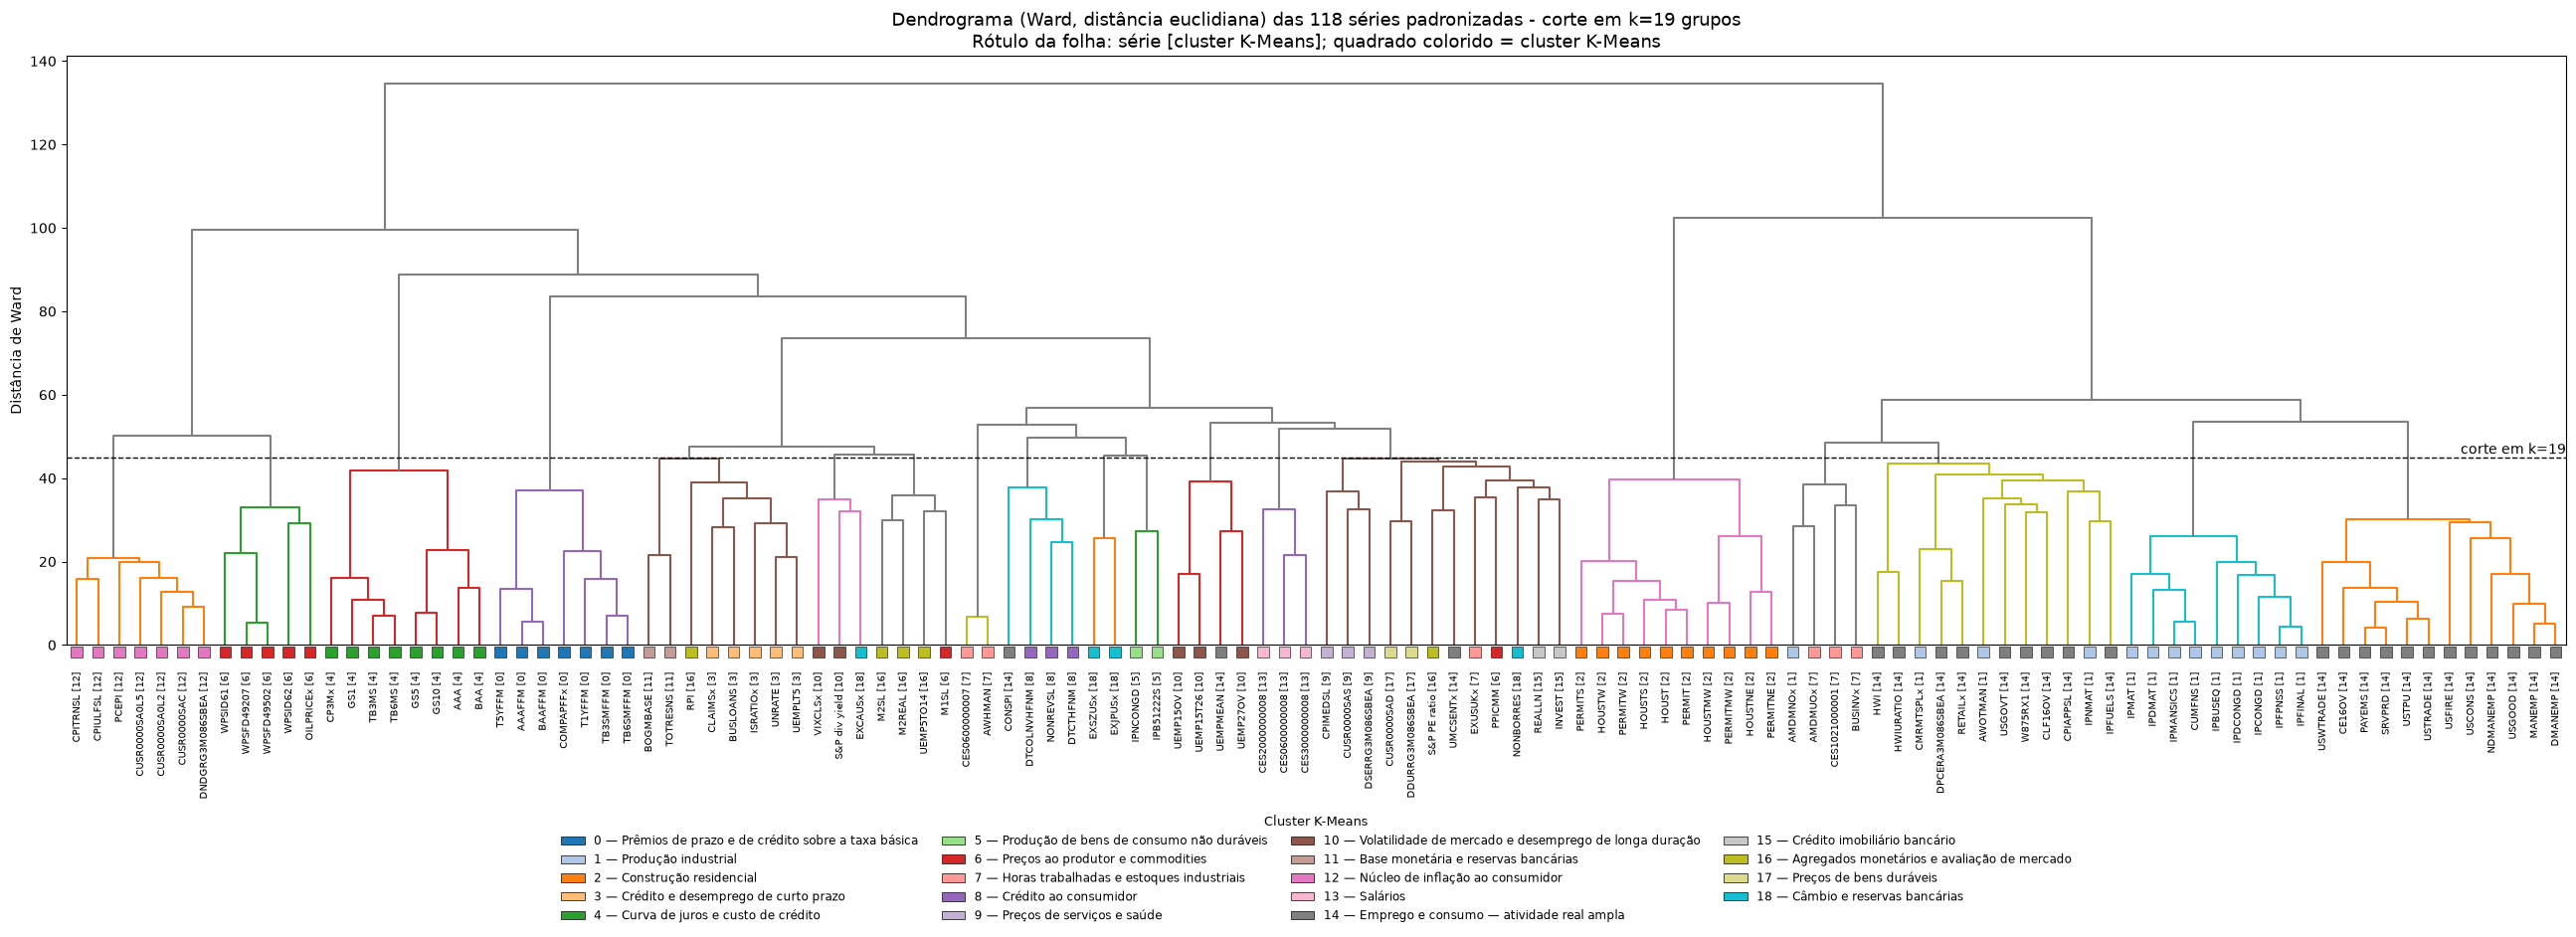

Salvo: dendrograma_ward.png


In [38]:
# Dendrograma do Ward com corte em k=19. A linha tracejada fica no ponto médio entre as fusões que
# separam 20 de 19 grupos. Cada folha traz [cluster K-Means] e um quadrado com a cor tab20 do
# cluster, para ver onde os dois métodos concordam.
from scipy.cluster.hierarchy import dendrogram
from matplotlib.patches import Patch

altura_corte = (Z_ward[-(K - 1), 2] + Z_ward[-K, 2]) / 2
rotulos_folha = [f"{s} [{cluster_de[s]}]" for s in series_names]

fig, ax = plt.subplots(figsize=(26, 10))
dn = dendrogram(
    Z_ward, ax=ax, labels=rotulos_folha, leaf_rotation=90, leaf_font_size=7.5,
    color_threshold=altura_corte, above_threshold_color="gray",
)
ax.axhline(altura_corte, color="black", ls="--", lw=1)
ax.text(ax.get_xlim()[1], altura_corte, f"  corte em k={K}", va="bottom", ha="right", fontsize=10)

# quadrado colorido sob cada folha (folhas em x = 5, 15, 25, ...)
ordem_folhas = dn["leaves"]
xs = [5 + 10 * i for i in range(len(ordem_folhas))]
cores_folha = [cor_cluster[cluster_de[series_names[i]]] for i in ordem_folhas]
y_min, y_max = ax.get_ylim()
ax.scatter(xs, [-0.012 * (y_max - y_min)] * len(xs), c=cores_folha, marker="s", s=70,
           edgecolors="black", linewidths=0.4, clip_on=False, zorder=5)

ax.tick_params(axis="x", pad=16)  # afasta o rótulo do quadrado
ax.set_ylabel("Distância de Ward")
ax.set_title(
    f"Dendrograma (Ward, distância euclidiana) das 118 séries padronizadas - corte em k={K} grupos\n"
    "Rótulo da folha: série [cluster K-Means]; quadrado colorido = cluster K-Means",
    fontsize=13,
)
handles = [Patch(fc=cor_cluster[c], ec="black", lw=0.5, label=f"{c} — {ROTULO_CURTO[c]}") for c in range(K)]
ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.27), ncol=4, fontsize=8.5,
          title="Cluster K-Means", title_fontsize=9.5, frameon=False)
plt.tight_layout()
plt.savefig(FIGURAS / "dendrograma_ward.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: dendrograma_ward.png")